# Sieć Kohonena: KOH1 i KOH2

To nie jest klasyfikator uczony na etykietach. Sieć ma sama ułożyć dane na mapie neuronów, a etykiety pojawiają się dopiero po treningu, żeby sprawdzić, czy punkty z tej samej klasy faktycznie lądują blisko siebie.


In [1]:
from __future__ import annotations

import argparse
import gzip
import json
import struct
import urllib.request
import zipfile
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np

try:
    from numba import njit
except ImportError:  # pragma: no cover - optional speed-up
    njit = None


if njit is not None:

    @njit(cache=False)
    def _fit_weights_numba(
        x: np.ndarray,
        weights: np.ndarray,
        inter_distances: np.ndarray,
        orders: np.ndarray,
        sigma: float,
        learning_rate: float,
        decay_lambda: float,
        neighborhood_code: int,
    ) -> tuple[np.ndarray, np.ndarray]:
        num_epochs = orders.shape[0]
        num_neurons = weights.shape[0]
        input_dim = weights.shape[1]
        errors = np.empty(num_epochs, dtype=np.float64)
        global_step = 0
        for epoch in range(num_epochs):
            for order_pos in range(orders.shape[1]):
                sample_idx = orders[epoch, order_pos]
                bmu = 0
                best_distance = 1e308
                for neuron in range(num_neurons):
                    distance = 0.0
                    for dim in range(input_dim):
                        diff = weights[neuron, dim] - x[sample_idx, dim]
                        distance += diff * diff
                    if distance < best_distance:
                        best_distance = distance
                        bmu = neuron

                alpha = learning_rate * np.exp(-global_step / decay_lambda)
                for neuron in range(num_neurons):
                    d = inter_distances[bmu, neuron] / sigma
                    h = np.exp(-0.5 * d * d)
                    if neighborhood_code == 1:
                        h = (1.0 - d * d) * h
                    step = alpha * h
                    for dim in range(input_dim):
                        weights[neuron, dim] += step * (x[sample_idx, dim] - weights[neuron, dim])
                global_step += 1

            error_sum = 0.0
            for sample_idx in range(x.shape[0]):
                best_distance = 1e308
                for neuron in range(num_neurons):
                    distance = 0.0
                    for dim in range(input_dim):
                        diff = weights[neuron, dim] - x[sample_idx, dim]
                        distance += diff * diff
                    if distance < best_distance:
                        best_distance = distance
                error_sum += np.sqrt(best_distance)
            errors[epoch] = error_sum / x.shape[0]
        return weights, errors


    @njit(cache=False)
    def _winner_indices_numba(x: np.ndarray, weights: np.ndarray) -> np.ndarray:
        winners = np.empty(x.shape[0], dtype=np.int64)
        num_neurons = weights.shape[0]
        input_dim = weights.shape[1]
        for sample_idx in range(x.shape[0]):
            bmu = 0
            best_distance = 1e308
            for neuron in range(num_neurons):
                distance = 0.0
                for dim in range(input_dim):
                    diff = weights[neuron, dim] - x[sample_idx, dim]
                    distance += diff * diff
                if distance < best_distance:
                    best_distance = distance
                    bmu = neuron
            winners[sample_idx] = bmu
        return winners
else:
    _fit_weights_numba = None
    _winner_indices_numba = None


def to_python(value):
    if isinstance(value, dict):
        return {to_python(k): to_python(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_python(v) for v in value]
    if isinstance(value, tuple):
        return [to_python(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, np.generic):
        return value.item()
    return value


def zscore_fit(x: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = x.mean(axis=0)
    std = x.std(axis=0)
    std[std == 0.0] = 1.0
    return mean, std


def zscore_transform(x: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return (x - mean) / std


def inverse_zscore(x: np.ndarray, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
    return x * std + mean


def read_csv_dataset(path: Path) -> tuple[np.ndarray, np.ndarray]:
    data = np.genfromtxt(path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    names = list(data.dtype.names or [])
    feature_cols = [c for c in ("x", "y", "z") if c in names]
    if not feature_cols or "c" not in names:
        raise ValueError(f"Niepoprawny format CSV: {path}")
    x = np.column_stack([np.asarray(data[c], dtype=np.float64) for c in feature_cols])
    y = np.asarray(data["c"])
    return x, y


def read_idx_images(path: Path) -> np.ndarray:
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rb") as f:
        magic, count, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Niepoprawny plik IDX obrazow: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(count, rows * cols).astype(np.float64)


def read_idx_labels(path: Path) -> np.ndarray:
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rb") as f:
        magic, count = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Niepoprawny plik IDX etykiet: {path}")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data[:count]


def read_matrix_txt(path: Path) -> np.ndarray:
    return np.loadtxt(path, dtype=np.float64)


def download_file(url: str, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.stat().st_size > 0:
        return
    urllib.request.urlretrieve(url, path)


def discover_mnist(root: Path) -> tuple[np.ndarray, np.ndarray]:
    csv_candidates = []
    for pattern in ("*mnist*.csv", "train.csv", "mnist_train.csv", "mnist_test.csv"):
        csv_candidates.extend(root.rglob(pattern))
    csv_candidates = [p for p in csv_candidates if p.is_file()]
    if csv_candidates:
        arrays = []
        labels = []
        for path in sorted(csv_candidates):
            data = np.genfromtxt(path, delimiter=",", names=True, dtype=np.float64, encoding="utf-8")
            cols = list(data.dtype.names or [])
            if not cols:
                continue
            if "label" in cols:
                y = np.asarray(data["label"], dtype=np.int64)
                x_cols = [c for c in cols if c != "label"]
            else:
                y = np.asarray(data[cols[0]], dtype=np.int64)
                x_cols = cols[1:]
            x = np.column_stack([np.asarray(data[c], dtype=np.float64) for c in x_cols])
            arrays.append(x)
            labels.append(y)
        if arrays:
            return np.vstack(arrays), np.concatenate(labels)

    image_patterns = [
        "train-images-idx3-ubyte",
        "train-images-idx3-ubyte.gz",
        "*train-images-idx3-ubyte*",
    ]
    label_patterns = [
        "train-labels-idx1-ubyte",
        "train-labels-idx1-ubyte.gz",
        "*train-labels-idx1-ubyte*",
    ]
    image_files = []
    label_files = []
    for pattern in image_patterns:
        image_files.extend(root.rglob(pattern))
    for pattern in label_patterns:
        label_files.extend(root.rglob(pattern))
    if image_files and label_files:
        image_path = sorted(set(image_files))[0]
        label_path = sorted(set(label_files))[0]
        return read_idx_images(image_path), read_idx_labels(label_path)

    mnist_dir = root / "data" / "mnist"
    image_path = mnist_dir / "train-images-idx3-ubyte.gz"
    label_path = mnist_dir / "train-labels-idx1-ubyte.gz"
    download_file("https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz", image_path)
    download_file("https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz", label_path)
    if image_path.exists() and label_path.exists():
        return read_idx_images(image_path), read_idx_labels(label_path)

    try:
        from sklearn.datasets import fetch_openml

        mnist = fetch_openml("mnist_784", version=1, as_frame=False)
        x = mnist.data.astype(np.float64)
        y = mnist.target.astype(np.int64)
        return x, y
    except Exception as exc:
        raise FileNotFoundError("Nie znaleziono lokalnego zbioru MNIST.") from exc


def try_load_har_from_tree(root: Path) -> tuple[np.ndarray, np.ndarray] | None:
    dirs = [p for p in root.rglob("*") if p.is_dir() and p.name.lower() in {"uci har dataset", "har"}]
    candidates = dirs + [root]
    for base in candidates:
        x_train = base / "train" / "X_train.txt"
        y_train = base / "train" / "y_train.txt"
        x_test = base / "test" / "X_test.txt"
        y_test = base / "test" / "y_test.txt"
        if x_train.exists() and y_train.exists():
            x_parts = [read_matrix_txt(x_train)]
            y_parts = [np.loadtxt(y_train, dtype=np.int64)]
            if x_test.exists() and y_test.exists():
                x_parts.append(read_matrix_txt(x_test))
                y_parts.append(np.loadtxt(y_test, dtype=np.int64))
            return np.vstack(x_parts), np.concatenate(y_parts)
    return None


def discover_har(root: Path) -> tuple[np.ndarray, np.ndarray]:
    loaded = try_load_har_from_tree(root)
    if loaded is not None:
        return loaded

    data_dir = root / "data"
    archive = data_dir / "UCI_HAR_Dataset.zip"
    download_file(
        "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip",
        archive,
    )
    if archive.exists() and archive.stat().st_size > 0:
        data_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(data_dir)
        for nested in data_dir.glob("*.zip"):
            if nested == archive:
                continue
            with zipfile.ZipFile(nested) as zf:
                zf.extractall(data_dir)
        loaded = try_load_har_from_tree(root)
        if loaded is not None:
            return loaded
    raise FileNotFoundError("Nie znaleziono lokalnego zbioru UCI HAR.")


def load_dataset(name: str, root: Path) -> tuple[np.ndarray, np.ndarray]:
    name = name.lower()
    if name == "hexagon":
        return read_csv_dataset(root / "koh" / "mio2" / "hexagon.csv")
    if name == "cube":
        return read_csv_dataset(root / "koh" / "mio2" / "cube.csv")
    if name == "mnist":
        return discover_mnist(root)
    if name == "har":
        return discover_har(root)
    raise ValueError(f"Nieznany zbior: {name}")


@dataclass
class DatasetBundle:
    name: str
    x_train: np.ndarray
    y_eval: np.ndarray
    feature_mean: np.ndarray
    feature_std: np.ndarray

    @classmethod
    def from_raw(cls, name: str, x: np.ndarray, y: np.ndarray) -> "DatasetBundle":
        mean, std = zscore_fit(x)
        return cls(name=name, x_train=zscore_transform(x, mean, std), y_eval=y, feature_mean=mean, feature_std=std)


class KohonenNetwork:
    def __init__(
        self,
        rows: int,
        cols: int,
        input_dim: int,
        topology: str = "rectangular",
        neighborhood: str = "gaussian",
        sigma: float = 1.5,
        learning_rate: float = 0.6,
        decay_lambda: float = 600.0,
        random_state: int = 42,
    ) -> None:
        self.rows = rows
        self.cols = cols
        self.input_dim = input_dim
        self.topology = topology
        self.neighborhood = neighborhood
        self.sigma = float(sigma)
        self.learning_rate = float(learning_rate)
        self.decay_lambda = float(decay_lambda)
        self.rng = np.random.default_rng(random_state)
        self.num_neurons = rows * cols
        self.grid_coords = self._build_grid_coords()
        self.inter_neuron_distances = self._build_inter_neuron_distances()
        self.weights = np.empty((self.num_neurons, input_dim), dtype=np.float64)
        self.quantization_errors_: list[float] = []

    def _build_grid_coords(self) -> np.ndarray:
        if self.topology == "rectangular":
            rr, cc = np.meshgrid(np.arange(self.rows), np.arange(self.cols), indexing="ij")
            return np.column_stack([rr.ravel(), cc.ravel()]).astype(np.float64)
        if self.topology == "hexagonal":
            rr, cc = np.meshgrid(np.arange(self.rows), np.arange(self.cols), indexing="ij")
            return np.column_stack([cc.ravel(), rr.ravel()]).astype(np.int64)
        raise ValueError(f"Nieznana topologia: {self.topology}")

    def _build_inter_neuron_distances(self) -> np.ndarray:
        if self.topology == "rectangular":
            diff = self.grid_coords[:, None, :] - self.grid_coords[None, :, :]
            return np.sqrt((diff**2).sum(axis=2))
        q = self.grid_coords[:, 0]
        r = self.grid_coords[:, 1]
        x = q
        z = r
        y = -x - z
        cube = np.column_stack([x, y, z]).astype(np.int64)
        diff = np.abs(cube[:, None, :] - cube[None, :, :])
        return diff.max(axis=2).astype(np.float64)

    def _neighbor_kernel(self, bmu_index: int) -> np.ndarray:
        d = self.inter_neuron_distances[bmu_index] / self.sigma
        if self.neighborhood == "gaussian":
            return np.exp(-0.5 * d * d)
        if self.neighborhood == "mexican_hat":
            return (1.0 - d * d) * np.exp(-0.5 * d * d)
        raise ValueError(f"Nieznana funkcja sasiedztwa: {self.neighborhood}")

    def initialize(self, x: np.ndarray) -> None:
        if len(x) < self.num_neurons:
            reps = int(np.ceil(self.num_neurons / len(x)))
            pool = np.tile(x, (reps, 1))
        else:
            pool = x
        indices = self.rng.choice(len(pool), size=self.num_neurons, replace=False)
        self.weights = pool[indices].copy()

    def winner_indices(self, x: np.ndarray) -> np.ndarray:
        if _winner_indices_numba is not None:
            return _winner_indices_numba(
                x.astype(np.float64, copy=False),
                self.weights.astype(np.float64, copy=False),
            )
        sq = ((x[:, None, :] - self.weights[None, :, :]) ** 2).sum(axis=2)
        return np.argmin(sq, axis=1)

    def fit(self, x: np.ndarray, epochs: int = 100) -> "KohonenNetwork":
        self.initialize(x)
        if _fit_weights_numba is not None:
            orders = np.vstack([self.rng.permutation(len(x)) for _ in range(epochs)]).astype(np.int64)
            neighborhood_code = 0 if self.neighborhood == "gaussian" else 1
            self.weights, errors = _fit_weights_numba(
                x.astype(np.float64, copy=False),
                self.weights.astype(np.float64, copy=False),
                self.inter_neuron_distances.astype(np.float64, copy=False),
                orders,
                self.sigma,
                self.learning_rate,
                self.decay_lambda,
                neighborhood_code,
            )
            self.quantization_errors_ = [float(v) for v in errors]
            return self

        global_step = 0
        for _ in range(epochs):
            order = self.rng.permutation(len(x))
            x_epoch = x[order]
            for sample in x_epoch:
                sq = ((self.weights - sample) ** 2).sum(axis=1)
                bmu = int(np.argmin(sq))
                alpha = self.learning_rate * np.exp(-global_step / self.decay_lambda)
                h = self._neighbor_kernel(bmu)[:, None]
                self.weights += alpha * h * (sample - self.weights)
                global_step += 1
            bmu_indices = self.winner_indices(x)
            qe = np.linalg.norm(x - self.weights[bmu_indices], axis=1).mean()
            self.quantization_errors_.append(float(qe))
        return self

    def weights_grid(self) -> np.ndarray:
        return self.weights.reshape(self.rows, self.cols, self.input_dim)

    def neuron_positions(self, mean: np.ndarray | None = None, std: np.ndarray | None = None) -> np.ndarray:
        if mean is None or std is None:
            return self.weights.copy()
        return inverse_zscore(self.weights, mean, std)

    def neuron_index_to_grid(self, flat_indices: np.ndarray) -> np.ndarray:
        return np.column_stack(np.unravel_index(flat_indices, (self.rows, self.cols)))

    def adjacency_pairs(self) -> list[tuple[int, int]]:
        pairs = []
        for idx in range(self.num_neurons):
            distances = self.inter_neuron_distances[idx]
            neighbors = np.where(np.isclose(distances, 1.0))[0]
            for jdx in neighbors:
                if idx < jdx:
                    pairs.append((idx, jdx))
        return pairs


def summarize_neuron_classes(num_neurons: int, bmu_indices: np.ndarray, labels: np.ndarray) -> list[dict]:
    counts = [Counter() for _ in range(num_neurons)]
    for neuron, label in zip(bmu_indices, labels):
        counts[int(neuron)][label.item() if isinstance(label, np.generic) else label] += 1
    summary = []
    for neuron_id, counter in enumerate(counts):
        total = int(sum(counter.values()))
        majority_label = None
        majority_count = 0
        purity = None
        if total > 0:
            majority_label, majority_count = counter.most_common(1)[0]
            purity = majority_count / total
        summary.append(
            {
                "neuron_id": neuron_id,
                "total": total,
                "majority_label": majority_label,
                "purity": purity,
                "class_counts": dict(sorted(counter.items(), key=lambda kv: kv[0])),
            }
        )
    return summary


def connected_components(nodes: list[int], adjacency: dict[int, list[int]]) -> list[list[int]]:
    unseen = set(nodes)
    components = []
    while unseen:
        start = unseen.pop()
        stack = [start]
        comp = [start]
        while stack:
            cur = stack.pop()
            for nxt in adjacency.get(cur, []):
                if nxt in unseen:
                    unseen.remove(nxt)
                    stack.append(nxt)
                    comp.append(nxt)
        components.append(sorted(comp))
    return sorted(components, key=lambda c: (len(c), c), reverse=True)


def extract_label_clusters(
    model: KohonenNetwork,
    neuron_summary: list[dict],
    bmu_indices: np.ndarray,
    labels: np.ndarray,
) -> dict:
    active_neurons = [item["neuron_id"] for item in neuron_summary if item["total"] > 0]
    active_set = set(active_neurons)
    class_adjacency: dict[int, list[int]] = defaultdict(list)
    for a, b in model.adjacency_pairs():
        if a not in active_set or b not in active_set:
            continue
        label_a = neuron_summary[a]["majority_label"]
        label_b = neuron_summary[b]["majority_label"]
        if label_a is not None and label_a == label_b:
            class_adjacency[a].append(b)
            class_adjacency[b].append(a)
    components = connected_components(active_neurons, class_adjacency)
    label_counts = Counter(labels.tolist())
    cluster_details = []
    for cluster_id, neurons in enumerate(components):
        member_mask = np.isin(bmu_indices, neurons)
        member_labels = labels[member_mask]
        distribution = Counter(member_labels.tolist())
        majority_label, majority_count = distribution.most_common(1)[0]
        cluster_details.append(
            {
                "cluster_id": cluster_id,
                "neurons": neurons,
                "size": int(member_mask.sum()),
                "majority_label": majority_label,
                "purity": majority_count / len(member_labels),
                "label_distribution": dict(sorted(distribution.items(), key=lambda kv: kv[0])),
            }
        )
    return {
        "num_true_classes": len(label_counts),
        "num_occupied_neurons": len(active_neurons),
        "num_label_components": len(cluster_details),
        "clusters": cluster_details,
    }


def evaluate_model(model: KohonenNetwork, bundle: DatasetBundle) -> dict:
    bmu_indices = model.winner_indices(bundle.x_train)
    grid_positions = model.neuron_index_to_grid(bmu_indices)
    neuron_summary = summarize_neuron_classes(model.num_neurons, bmu_indices, bundle.y_eval)
    occupied = [item for item in neuron_summary if item["total"] > 0]
    pure_occupied = [item for item in occupied if item["purity"] == 1.0]
    entropy_values = []
    for item in occupied:
        probs = np.asarray(list(item["class_counts"].values()), dtype=np.float64) / item["total"]
        entropy_values.append(float(-(probs * np.log2(probs + 1e-12)).sum()))
    cluster_summary = extract_label_clusters(model, neuron_summary, bmu_indices, bundle.y_eval)
    mean_positions = model.neuron_positions(bundle.feature_mean, bundle.feature_std) if model.input_dim <= 3 else []
    per_label_neurons = defaultdict(list)
    for neuron_id, label in zip(bmu_indices, bundle.y_eval):
        per_label_neurons[label.item() if isinstance(label, np.generic) else label].append(int(neuron_id))
    label_neuron_spread = {
        label: dict(sorted(Counter(neurons).items(), key=lambda kv: (kv[1], kv[0]), reverse=True))
        for label, neurons in sorted(per_label_neurons.items(), key=lambda kv: kv[0])
    }
    return {
        "dataset": bundle.name,
        "topology": model.topology,
        "neighborhood": model.neighborhood,
        "grid_shape": [model.rows, model.cols],
        "input_dim": model.input_dim,
        "epochs": len(model.quantization_errors_),
        "sigma": model.sigma,
        "learning_rate": model.learning_rate,
        "decay_lambda": model.decay_lambda,
        "quantization_error_final": model.quantization_errors_[-1],
        "quantization_error_curve": model.quantization_errors_,
        "occupied_neurons": len(occupied),
        "fully_pure_occupied_neurons": len(pure_occupied),
        "fraction_single_class_neurons": len(pure_occupied) / max(len(occupied), 1),
        "mean_neuron_entropy": float(np.mean(entropy_values)) if entropy_values else 0.0,
        "sample_bmu_grid_positions": grid_positions.tolist(),
        "neuron_positions_input_space": mean_positions.tolist() if model.input_dim <= 3 else [],
        "neuron_class_summary": neuron_summary,
        "label_neuron_spread": label_neuron_spread,
        "cluster_summary": cluster_summary,
    }


DEFAULT_PRESETS = {
    "hexagon": {"rows": 3, "cols": 3, "epochs": 180, "sigma": 1.2, "learning_rate": 0.55, "decay_lambda": 900.0},
    "cube": {"rows": 4, "cols": 4, "epochs": 220, "sigma": 1.4, "learning_rate": 0.5, "decay_lambda": 1400.0},
    "mnist": {"rows": 10, "cols": 10, "epochs": 20, "sigma": 2.1, "learning_rate": 0.35, "decay_lambda": 240000.0},
    "har": {"rows": 8, "cols": 8, "epochs": 25, "sigma": 1.8, "learning_rate": 0.4, "decay_lambda": 220000.0},
}


def run_experiment(
    root: Path,
    dataset_name: str,
    topology: str,
    neighborhood: str,
    rows: int | None,
    cols: int | None,
    epochs: int | None,
    sigma: float | None,
    learning_rate: float | None,
    decay_lambda: float | None,
    random_state: int,
    sample_limit: int | None,
) -> dict:
    x_raw, y = load_dataset(dataset_name, root)
    if sample_limit is not None and sample_limit < len(x_raw):
        rng = np.random.default_rng(random_state)
        idx = rng.choice(len(x_raw), size=sample_limit, replace=False)
        x_raw = x_raw[idx]
        y = y[idx]
    bundle = DatasetBundle.from_raw(dataset_name, x_raw, y)
    preset = DEFAULT_PRESETS[dataset_name]
    model = KohonenNetwork(
        rows=rows or preset["rows"],
        cols=cols or preset["cols"],
        input_dim=bundle.x_train.shape[1],
        topology=topology,
        neighborhood=neighborhood,
        sigma=sigma if sigma is not None else preset["sigma"],
        learning_rate=learning_rate if learning_rate is not None else preset["learning_rate"],
        decay_lambda=decay_lambda if decay_lambda is not None else preset["decay_lambda"],
        random_state=random_state,
    )
    model.fit(bundle.x_train, epochs=epochs or preset["epochs"])
    return evaluate_model(model, bundle)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--root", type=Path, default=Path(__file__).resolve().parent)
    parser.add_argument("--dataset", choices=["hexagon", "cube", "mnist", "har"], required=True)
    parser.add_argument("--topology", choices=["rectangular", "hexagonal"], default="rectangular")
    parser.add_argument("--neighborhood", choices=["gaussian", "mexican_hat"], default="gaussian")
    parser.add_argument("--rows", type=int)
    parser.add_argument("--cols", type=int)
    parser.add_argument("--epochs", type=int)
    parser.add_argument("--sigma", type=float)
    parser.add_argument("--learning-rate", type=float)
    parser.add_argument("--decay-lambda", type=float)
    parser.add_argument("--random-state", type=int, default=42)
    parser.add_argument("--sample-limit", type=int)
    parser.add_argument("--output", type=Path)
    return parser.parse_args()


def main() -> None:
    args = parse_args()
    result = run_experiment(
        root=args.root,
        dataset_name=args.dataset,
        topology=args.topology,
        neighborhood=args.neighborhood,
        rows=args.rows,
        cols=args.cols,
        epochs=args.epochs,
        sigma=args.sigma,
        learning_rate=args.learning_rate,
        decay_lambda=args.decay_lambda,
        random_state=args.random_state,
        sample_limit=args.sample_limit,
    )
    payload = json.dumps(to_python(result), ensure_ascii=False, indent=2)
    if args.output is not None:
        args.output.write_text(payload, encoding="utf-8")
    print(payload)

# Reporting imports and helpers
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Funkcje pomocnicze do notebooka





ROOT = Path.cwd()


def clean_label(value) -> str:
    return str(value).replace('"', "")


def format_counts(counts: dict) -> str:
    items = sorted(((clean_label(k), int(v)) for k, v in counts.items()), key=lambda kv: kv[0])
    return " | ".join(f"{k}:{v}" for k, v in items)


@dataclass
class CaseResult:
    dataset_name: str
    config: dict
    bundle: DatasetBundle
    model: KohonenNetwork
    result: dict
    bmu_indices: np.ndarray


def dataset_overview(dataset_name: str) -> dict:
    x, y = load_dataset(dataset_name, ROOT)
    labels = pd.Series([clean_label(v) for v in y], name="klasa")
    overview = pd.DataFrame(
        [
            {
                "zbior": dataset_name,
                "proby": int(len(x)),
                "cechy": int(x.shape[1]),
                "klasy": int(labels.nunique()),
                "min": np.round(x.min(axis=0), 6).tolist(),
                "max": np.round(x.max(axis=0), 6).tolist(),
            }
        ]
    )
    feature_cols = ["x", "y"] if x.shape[1] == 2 else ["x", "y", "z"]
    head = pd.DataFrame(x[:10], columns=feature_cols)
    head["c"] = labels.iloc[:10].tolist()
    class_counts = (
        labels.value_counts()
        .sort_index()
        .rename_axis("klasa")
        .reset_index(name="licznosc")
    )
    return {"overview": overview, "head": head, "class_counts": class_counts}


def run_case(
    dataset_name: str,
    neighborhood: str,
    rows: int,
    cols: int,
    epochs: int,
    sigma: float,
    learning_rate: float,
    decay_lambda: float,
    topology: str = "rectangular",
    seed: int = 42,
    sample_limit: int | None = None,
) -> CaseResult:
    x_raw, y = load_dataset(dataset_name, ROOT)
    if sample_limit is not None and sample_limit < len(x_raw):
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(x_raw), size=sample_limit, replace=False)
        x_raw = x_raw[idx]
        y = y[idx]
    bundle = DatasetBundle.from_raw(dataset_name, x_raw, y)
    model = KohonenNetwork(
        rows=rows,
        cols=cols,
        input_dim=bundle.x_train.shape[1],
        topology=topology,
        neighborhood=neighborhood,
        sigma=sigma,
        learning_rate=learning_rate,
        decay_lambda=decay_lambda,
        random_state=seed,
    )
    model.fit(bundle.x_train, epochs=epochs)
    result = evaluate_model(model, bundle)
    bmu_indices = model.winner_indices(bundle.x_train)
    return CaseResult(
        dataset_name=dataset_name,
        config={
            "dataset_name": dataset_name,
            "neighborhood": neighborhood,
            "rows": rows,
            "cols": cols,
            "topology": topology,
            "epochs": epochs,
            "sigma": sigma,
            "learning_rate": learning_rate,
            "decay_lambda": decay_lambda,
            "seed": seed,
            "sample_limit": sample_limit,
        },
        bundle=bundle,
        model=model,
        result=result,
        bmu_indices=bmu_indices,
    )


def occupied_items(case: CaseResult) -> list[dict]:
    return [item for item in case.result["neuron_class_summary"] if item["total"] > 0]


def case_overview_df(case: CaseResult) -> pd.DataFrame:
    occupied = occupied_items(case)
    purities = [float(item["purity"]) for item in occupied if item["purity"] is not None]
    pure_neurons = sum(abs(p - 1.0) < 1e-12 for p in purities)
    cluster_match = int(case.result["cluster_summary"]["num_label_components"]) == int(case.result["cluster_summary"]["num_true_classes"])
    return pd.DataFrame(
        [
            {
                "zbior": case.dataset_name,
                "topologia": case.config["topology"],
                "sasiedztwo": case.config["neighborhood"],
                "siatka": f'{case.config["rows"]}x{case.config["cols"]}',
                "epoki": case.config["epochs"],
                "sigma": case.config["sigma"],
                "alpha0": case.config["learning_rate"],
                "lambda": case.config["decay_lambda"],
                "seed": case.config["seed"],
                "blad_kwantyzacji": round(float(case.result["quantization_error_final"]), 6),
                "klasy_rzeczywiste": int(case.result["cluster_summary"]["num_true_classes"]),
                "klastry_na_mapie": int(case.result["cluster_summary"]["num_label_components"]),
                "zgodna_liczba_klastrow": cluster_match,
                "aktywne_neurony": int(case.result["occupied_neurons"]),
                "neurony_jednoklasowe": int(pure_neurons),
                "wszystkie_neurony_jednoklasowe": pure_neurons == len(occupied),
                "srednia_czystosc": round(float(np.mean(purities)) if purities else 0.0, 6),
                "min_czystosc": round(float(np.min(purities)) if purities else 0.0, 6),
            }
        ]
    )


def neuron_summary_df(case: CaseResult) -> pd.DataFrame:
    coords = case.model.neuron_index_to_grid(np.arange(case.model.num_neurons))
    rows = []
    for item in case.result["neuron_class_summary"]:
        neuron_id = int(item["neuron_id"])
        if item["total"] == 0:
            continue
        row, col = coords[neuron_id].tolist()
        rows.append(
            {
                "neuron": neuron_id,
                "wiersz": int(row),
                "kolumna": int(col),
                "licznosc": int(item["total"]),
                "klasa_wiekszosciowa": clean_label(item["majority_label"]),
                "czystosc": round(float(item["purity"]), 6),
                "rozklad_klas": format_counts(item["class_counts"]),
            }
        )
    return pd.DataFrame(rows).sort_values(["wiersz", "kolumna"]).reset_index(drop=True)


def neuron_positions_df(case: CaseResult) -> pd.DataFrame:
    coords = case.model.neuron_index_to_grid(np.arange(case.model.num_neurons))
    positions = case.model.neuron_positions(case.bundle.feature_mean, case.bundle.feature_std)
    rows = []
    for idx, pos in enumerate(positions):
        row, col = coords[idx].tolist()
        payload = {"neuron": int(idx), "wiersz": int(row), "kolumna": int(col)}
        for name, value in zip(["x", "y", "z"][: positions.shape[1]], pos):
            payload[name] = round(float(value), 6)
        rows.append(payload)
    return pd.DataFrame(rows)


def cluster_summary_df(case: CaseResult) -> pd.DataFrame:
    rows = []
    for item in case.result["cluster_summary"]["clusters"]:
        rows.append(
            {
                "klaster": int(item["cluster_id"]),
                "neurony": ", ".join(str(int(v)) for v in item["neurons"]),
                "licznosc": int(item["size"]),
                "klasa_wiekszosciowa": clean_label(item["majority_label"]),
                "czystosc": round(float(item["purity"]), 6),
                "rozklad_klas": format_counts(item["label_distribution"]),
            }
        )
    return pd.DataFrame(rows).sort_values("klaster").reset_index(drop=True)


def label_spread_df(case: CaseResult) -> pd.DataFrame:
    rows = []
    for label, spread in sorted(case.result["label_neuron_spread"].items(), key=lambda kv: clean_label(kv[0])):
        rows.append(
            {
                "klasa": clean_label(label),
                "neurony": format_counts({str(k): int(v) for k, v in spread.items()}),
            }
        )
    return pd.DataFrame(rows)


def focused_search(
    dataset_name: str,
    grid_options: list[tuple[int, int]],
    sigma_values: list[float],
    neighborhoods: list[str],
    epochs: int,
    learning_rate: float,
    decay_lambda: float,
    topologies: list[str] | None = None,
    seed: int = 42,
    sample_limit: int | None = None,
    top_k: int = 12,
) -> pd.DataFrame:
    rows = []
    topologies = topologies or ["rectangular"]
    for topology in topologies:
        for neighborhood in neighborhoods:
            for grid_rows, grid_cols in grid_options:
                for sigma in sigma_values:
                    case = run_case(
                        dataset_name=dataset_name,
                        neighborhood=neighborhood,
                        rows=grid_rows,
                        cols=grid_cols,
                        epochs=epochs,
                        sigma=sigma,
                        learning_rate=learning_rate,
                        decay_lambda=decay_lambda,
                        topology=topology,
                        seed=seed,
                        sample_limit=sample_limit,
                    )
                    occupied = occupied_items(case)
                    purities = [float(item["purity"]) for item in occupied if item["purity"] is not None]
                    rows.append(
                        {
                            "zbior": dataset_name,
                            "topologia": topology,
                            "sasiedztwo": neighborhood,
                            "siatka": f"{grid_rows}x{grid_cols}",
                            "sigma": sigma,
                            "blad_kwantyzacji": float(case.result["quantization_error_final"]),
                            "klasy_rzeczywiste": int(case.result["cluster_summary"]["num_true_classes"]),
                            "klastry_na_mapie": int(case.result["cluster_summary"]["num_label_components"]),
                            "aktywne_neurony": int(case.result["occupied_neurons"]),
                            "srednia_czystosc": float(np.mean(purities)) if purities else 0.0,
                            "min_czystosc": float(np.min(purities)) if purities else 0.0,
                            "roznica_liczby_klastrow": abs(
                                int(case.result["cluster_summary"]["num_label_components"])
                                - int(case.result["cluster_summary"]["num_true_classes"])
                            ),
                        }
                    )
    frame = pd.DataFrame(rows)
    frame = frame.sort_values(
        [
            "roznica_liczby_klastrow",
            "srednia_czystosc",
            "min_czystosc",
            "blad_kwantyzacji",
        ],
        ascending=[True, False, False, True],
    ).reset_index(drop=True)
    numeric_cols = ["sigma", "blad_kwantyzacji", "srednia_czystosc", "min_czystosc"]
    frame[numeric_cols] = frame[numeric_cols].round(6)
    return frame.head(top_k)


def plot_training_curve(case: CaseResult) -> None:
    fig, ax = plt.subplots(figsize=(7, 4))
    curve = np.asarray(case.result["quantization_error_curve"], dtype=np.float64)
    ax.plot(np.arange(1, len(curve) + 1), curve, linewidth=2.0)
    ax.set_title("Krzywa błędu kwantyzacji")
    ax.set_xlabel("Epoka")
    ax.set_ylabel("Błąd")
    ax.grid(alpha=0.3)
    plt.show()


def plot_embedding(case: CaseResult) -> None:
    x_raw, y = load_dataset(case.dataset_name, ROOT)
    if case.config.get("sample_limit") is not None and case.config["sample_limit"] < len(x_raw):
        rng = np.random.default_rng(case.config["seed"])
        idx = rng.choice(len(x_raw), size=case.config["sample_limit"], replace=False)
        x_raw = x_raw[idx]
        y = y[idx]
    labels = np.asarray([clean_label(v) for v in y])
    unique_labels = sorted(pd.unique(labels))
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    colors = np.asarray([label_to_int[label] for label in labels])
    neuron_positions = case.model.neuron_positions(case.bundle.feature_mean, case.bundle.feature_std)
    if x_raw.shape[1] == 2:
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(x_raw[:, 0], x_raw[:, 1], c=colors, cmap="tab10", s=14, alpha=0.65)
        for left, right in case.model.adjacency_pairs():
            pair = neuron_positions[[left, right]]
            ax.plot(pair[:, 0], pair[:, 1], color="black", linewidth=1.0, alpha=0.75)
        ax.scatter(
            neuron_positions[:, 0],
            neuron_positions[:, 1],
            marker="X",
            s=180,
            c="white",
            edgecolors="black",
            linewidths=1.5,
        )
        for idx, (px, py) in enumerate(neuron_positions):
            ax.text(px, py, str(idx), fontsize=9, ha="center", va="center")
        ax.set_title("Dane i pozycje neuronów")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(alpha=0.2)
        plt.show()
        return
    if x_raw.shape[1] > 3:
        try:
            from sklearn.decomposition import PCA
        except ImportError:
            return
        pca = PCA(n_components=2, random_state=case.config["seed"])
        projected_x = pca.fit_transform(x_raw)
        projected_neurons = pca.transform(neuron_positions)
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(projected_x[:, 0], projected_x[:, 1], c=colors, cmap="tab10", s=10, alpha=0.55)
        for left, right in case.model.adjacency_pairs():
            pair = projected_neurons[[left, right]]
            ax.plot(pair[:, 0], pair[:, 1], color="black", linewidth=0.9, alpha=0.7)
        ax.scatter(
            projected_neurons[:, 0],
            projected_neurons[:, 1],
            marker="X",
            s=90,
            c="white",
            edgecolors="black",
            linewidths=1.2,
        )
        ax.set_title("Rzut PCA danych i neuronow")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(alpha=0.2)
        plt.show()
        return
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(x_raw[:, 0], x_raw[:, 1], x_raw[:, 2], c=colors, cmap="tab10", s=10, alpha=0.55)
    for left, right in case.model.adjacency_pairs():
        pair = neuron_positions[[left, right]]
        ax.plot(pair[:, 0], pair[:, 1], pair[:, 2], color="black", linewidth=1.0, alpha=0.75)
    ax.scatter(
        neuron_positions[:, 0],
        neuron_positions[:, 1],
        neuron_positions[:, 2],
        marker="X",
        s=160,
        c="white",
        edgecolors="black",
        linewidths=1.5,
    )
    for idx, (px, py, pz) in enumerate(neuron_positions):
        ax.text(px, py, pz, str(idx), fontsize=8)
    ax.set_title("Dane i pozycje neuronów")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    plt.show()


def plot_grid_maps(case: CaseResult) -> None:
    summary = neuron_summary_df(case)
    counts = np.zeros((case.model.rows, case.model.cols), dtype=np.float64)
    purity = np.full((case.model.rows, case.model.cols), np.nan)
    labels = np.full((case.model.rows, case.model.cols), "", dtype=object)
    for _, row in summary.iterrows():
        r = int(row["wiersz"])
        c = int(row["kolumna"])
        counts[r, c] = float(row["licznosc"])
        purity[r, c] = float(row["czystosc"])
        labels[r, c] = str(row["klasa_wiekszosciowa"])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    im0 = axes[0].imshow(counts, cmap="Blues")
    axes[0].set_title("Liczność neuronu")
    axes[0].set_xlabel("Kolumna")
    axes[0].set_ylabel("Wiersz")
    for r in range(case.model.rows):
        for c in range(case.model.cols):
            axes[0].text(c, r, int(counts[r, c]), ha="center", va="center", fontsize=10)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(np.nan_to_num(purity, nan=0.0), cmap="YlGn", vmin=0.0, vmax=1.0)
    axes[1].set_title("Czystość neuronu")
    axes[1].set_xlabel("Kolumna")
    axes[1].set_ylabel("Wiersz")
    for r in range(case.model.rows):
        for c in range(case.model.cols):
            text = "-" if np.isnan(purity[r, c]) else f'{purity[r, c]:.3f}\n{labels[r, c]}'
            axes[1].text(c, r, text, ha="center", va="center", fontsize=9)
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_u_matrix(case: CaseResult) -> None:
    matrix = np.full((case.model.rows, case.model.cols), np.nan, dtype=np.float64)
    for idx in range(case.model.num_neurons):
        row, col = case.model.neuron_index_to_grid(np.asarray([idx]))[0]
        neighbors = np.where(np.isclose(case.model.inter_neuron_distances[idx], 1.0))[0]
        if len(neighbors) == 0:
            continue
        distances = np.linalg.norm(case.model.weights[neighbors] - case.model.weights[idx], axis=1)
        matrix[int(row), int(col)] = float(distances.mean())
    fig, ax = plt.subplots(figsize=(5.6, 4.4))
    image = ax.imshow(np.nan_to_num(matrix, nan=0.0), cmap="magma")
    ax.set_title("U-Matrix")
    ax.set_xlabel("Kolumna")
    ax.set_ylabel("Wiersz")
    for row in range(case.model.rows):
        for col in range(case.model.cols):
            text = "-" if np.isnan(matrix[row, col]) else f"{matrix[row, col]:.3f}"
            ax.text(col, row, text, ha="center", va="center", fontsize=9, color="white")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def display_case(case: CaseResult) -> None:
    display(case_overview_df(case))
    display(cluster_summary_df(case))
    if case.model.input_dim <= 3:
        display(neuron_positions_df(case))
    display(neuron_summary_df(case))
    display(label_spread_df(case))
    plot_training_curve(case)
    plot_embedding(case)
    plot_grid_maps(case)
    plot_u_matrix(case)


def task_checklist_df(cases: list[CaseResult]) -> pd.DataFrame:
    rows = []
    for case in cases:
        occupied = occupied_items(case)
        purities = [float(item["purity"]) for item in occupied if item["purity"] is not None]
        rows.append(
            {
                "zbior": case.dataset_name,
                "topologia": case.config["topology"],
                "sasiedztwo": case.config["neighborhood"],
                "siatka": f'{case.config["rows"]}x{case.config["cols"]}',
                "sigma": case.config["sigma"],
                "spelnia_topologie": case.model.topology in {"rectangular", "hexagonal"},
                "spelnia_gauss_lub_mexican_hat": case.config["neighborhood"] in {"gaussian", "mexican_hat"},
                "spelnia_tlumienie_alpha": case.config["decay_lambda"] > 0,
                "zgodna_liczba_klastrow": int(case.result["cluster_summary"]["num_label_components"]) == int(case.result["cluster_summary"]["num_true_classes"]),
                "wszystkie_neurony_jednoklasowe": all(abs(p - 1.0) < 1e-12 for p in purities),
                "pozycje_neuronow_wyznaczone": True,
                "licznosci_klas_w_neuronach_wyznaczone": True,
                "blad_kwantyzacji": round(float(case.result["quantization_error_final"]), 6),
                "srednia_czystosc": round(float(np.mean(purities)) if purities else 0.0, 6),
                "min_czystosc": round(float(np.min(purities)) if purities else 0.0, 6),
            }
        )
    return pd.DataFrame(rows)

# Architektura i parametry

Każdy neuron przechowuje wektor wag o tej samej długości co próbka danych. Dla próbki wybieram BMU, czyli neuron z najbliższymi wagami w sensie odległości euklidesowej. Potem BMU i jego sąsiedzi przesuwają się w stronę tej próbki. To jest uczenie online: aktualizacja następuje po każdej próbce, a nie po całej paczce danych.

Najważniejsze parametry są trzy. Sigma określa, jak szeroko aktualizacja rozlewa się po mapie. Alpha0 mówi, jak mocno ruszamy wagi na początku. Lambda steruje tempem wygaszania alpha0 w kolejnych iteracjach. Gaussian wygładza mapę, a Mexican hat dodatkowo odpycha dalsze neurony, więc potrafi wyostrzyć granice, ale jest bardziej kapryśny na danych wysokowymiarowych.


In [2]:
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)


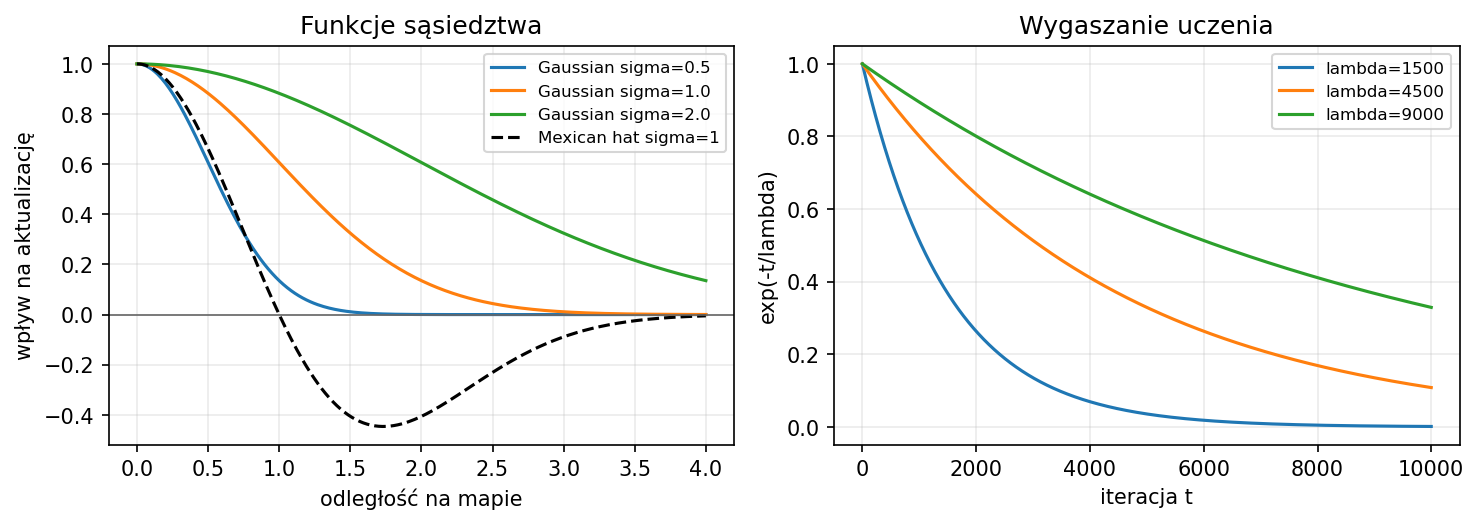

In [ ]:
# Kształt sąsiedztwa i wygaszania uczenia.
# Gaussian wygładza mapę, Mexican hat wzmacnia centrum i osłabia dalsze neurony.


# Dane

Hexagon to punkty 2D skupione przy wierzchołkach sześciokąta, a cube to punkty 3D skupione przy wierzchołkach sześcianu. W tych dwóch zbiorach łatwo sprawdzić, czy neurony ustawiają się tam, gdzie faktycznie są skupienia.

MNIST zawiera obrazy cyfr 0-9 zapisane jako 784 piksele. UCI HAR zawiera 561 cech z czujników telefonu dla sześciu aktywności człowieka. W KOH2 nie uczę modelu rozpoznawać etykiet; sprawdzam, czy mapa bez etykiet porządkuje cyfry i aktywności w sensowne obszary.


In [3]:
for dataset_name in ["hexagon", "cube"]:
    print(dataset_name.upper())
    info = dataset_overview(dataset_name)
    display(info["overview"])
    display(info["class_counts"])

large_rows = []
for dataset_name in ["mnist", "har"]:
    x, y = load_dataset(dataset_name, ROOT)
    large_rows.append({
        "zbior": dataset_name,
        "proby": int(len(x)),
        "cechy": int(x.shape[1]),
        "klasy": int(pd.Series(y).nunique()),
        "proby_uzyte_w_KOH2": int(len(x)),
    })
display(pd.DataFrame(large_rows))


HEXAGON


,zbior,proby,cechy,klasy,min,max
0,hexagon,600,2,6,"[-4.561541, -8.632626]","[4.727185, 8.188139]"


,klasa,licznosc
0,0,100
1,1,100
2,2,100
3,3,100
4,4,100
5,5,100


CUBE


,zbior,proby,cechy,klasy,min,max
0,cube,1200,3,8,"[-1.986048, -2.262178, -1.619699]","[4.996167, 6.078151, 3.621737]"


,klasa,licznosc
0,0,150
1,1,150
2,2,150
3,3,150
4,4,150
5,5,150
6,6,150
7,7,150


,zbior,proby,cechy,klasy,proby_uzyte_w_KOH2
0,mnist,60000,784,10,60000
1,har,10299,561,6,10299


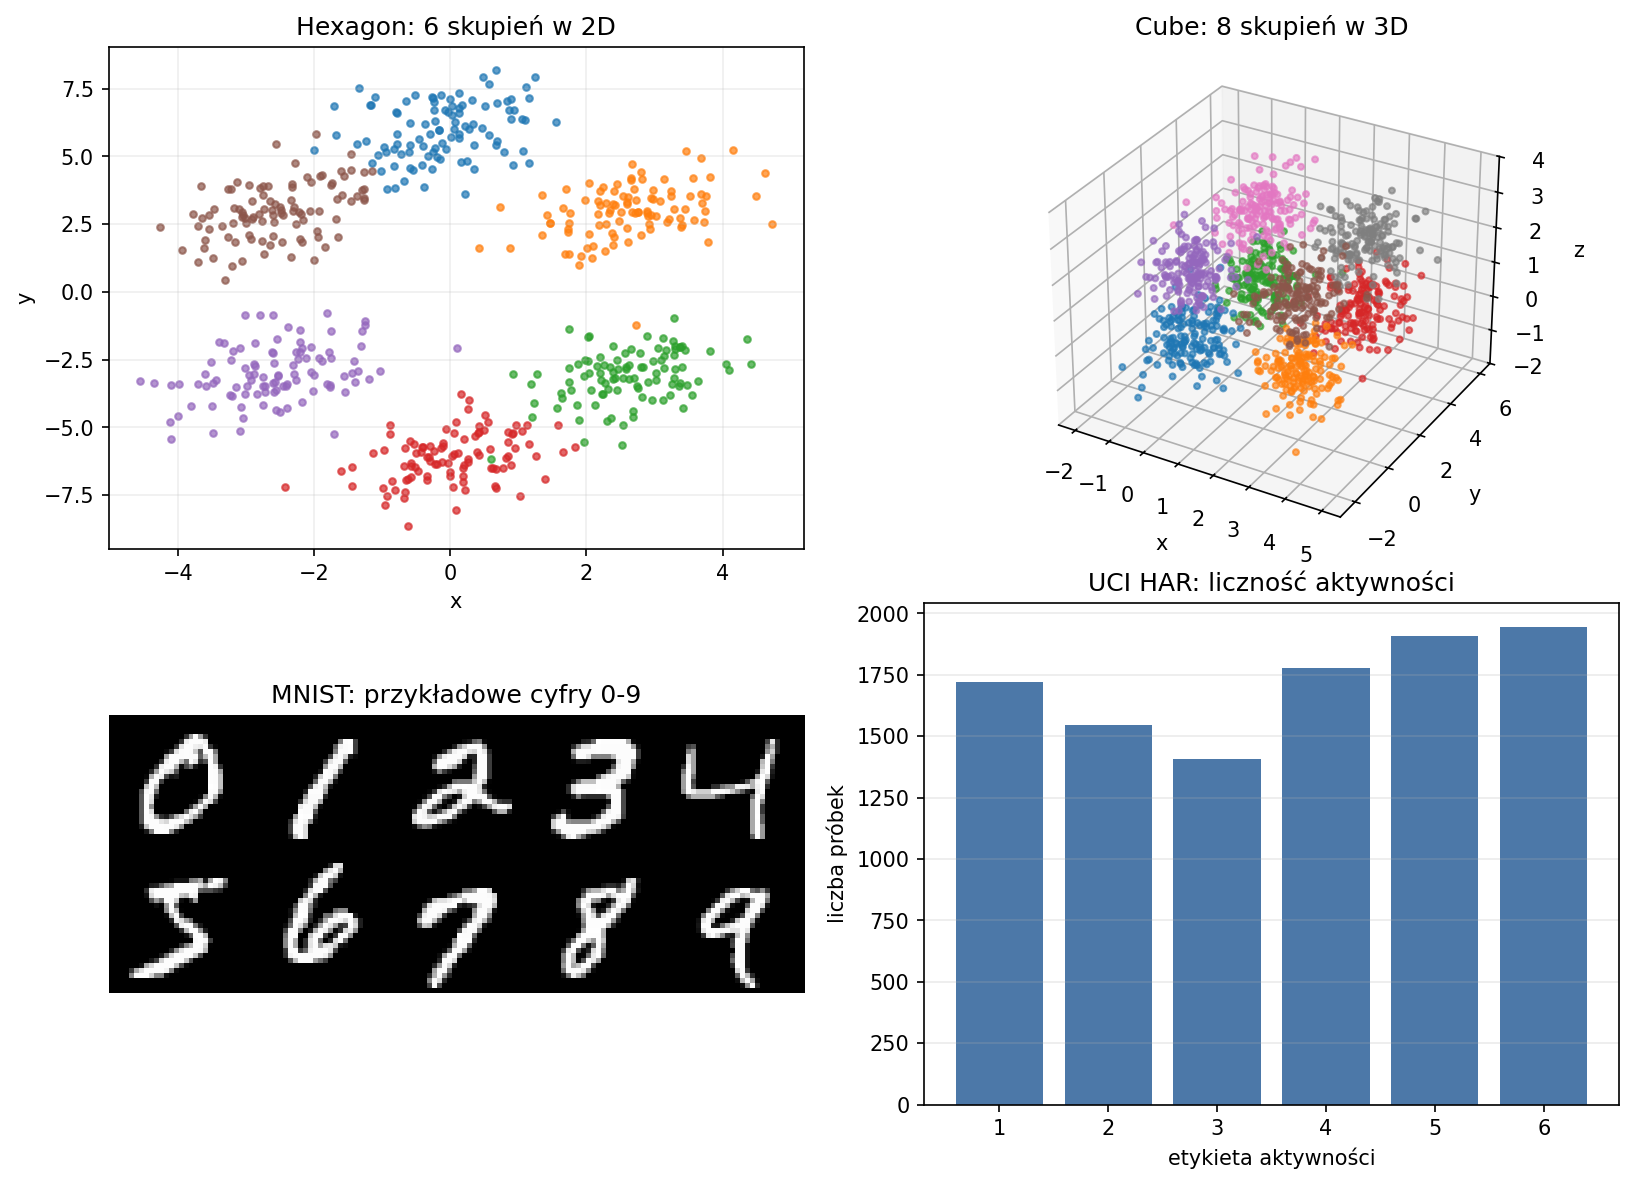

In [ ]:
# Podgląd danych użytych w pracy.
# Hexagon i cube są geometryczne, MNIST obrazkowy, HAR tabelaryczny z czujników telefonu.


# KOH1: strojenie

Tu cel jest prosty: znaleźć takie sigma, rozmiar mapy i sąsiedztwo, żeby liczba obszarów na mapie zgadzała się z liczbą wierzchołków figury. Dlatego w tabeli ważniejsze od samego błędu jest połączenie trzech rzeczy: zgodna liczba klastrów, wysoka czystość i brak pustej, zbyt dużej mapy.


In [4]:
hexagon_search = focused_search(
    dataset_name="hexagon",
    grid_options=[(2, 3), (3, 3)],
    sigma_values=[0.1, 0.2, 0.5, 0.75, 1.0, 2.5, 5.0, 10.0],
    neighborhoods=["gaussian", "mexican_hat"],
    epochs=180,
    learning_rate=0.55,
    decay_lambda=900.0,
    seed=42,
)
print("HEXAGON")
display(hexagon_search)

cube_search = focused_search(
    dataset_name="cube",
    grid_options=[(2, 4), (4, 4)],
    sigma_values=[0.1, 0.2, 0.5, 1.0, 2.5, 5.0, 10.0],
    neighborhoods=["gaussian", "mexican_hat"],
    epochs=220,
    learning_rate=0.5,
    decay_lambda=1400.0,
    seed=42,
)
print("CUBE")
display(cube_search)


HEXAGON


,zbior,topologia,sasiedztwo,siatka,sigma,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,aktywne_neurony,srednia_czystosc,min_czystosc,roznica_liczby_klastrow
0,hexagon,rectangular,gaussian,2x3,0.50,0.488804,6,6,6,0.981780,0.970000,0
1,hexagon,rectangular,gaussian,2x3,0.20,0.347279,6,6,6,0.978669,0.951923,0
2,hexagon,rectangular,gaussian,2x3,0.10,0.347279,6,6,6,0.978669,0.951923,0
3,hexagon,rectangular,mexican_hat,2x3,0.10,0.347279,6,6,6,0.978669,0.951923,0
4,hexagon,rectangular,mexican_hat,2x3,0.20,0.347284,6,6,6,0.978669,0.951923,0
5,hexagon,rectangular,gaussian,2x3,0.75,0.699444,6,6,6,0.952805,0.833333,0
6,hexagon,rectangular,mexican_hat,3x3,2.50,0.633946,6,6,8,0.864557,0.694915,0
7,hexagon,rectangular,gaussian,3x3,0.75,0.468590,6,6,9,0.846597,0.500000,0
8,hexagon,rectangular,mexican_hat,3x3,5.00,1.233448,6,6,7,0.837118,0.524064,0
9,hexagon,rectangular,gaussian,3x3,2.50,1.206846,6,6,8,0.828882,0.530055,0


CUBE


,zbior,topologia,sasiedztwo,siatka,sigma,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,aktywne_neurony,srednia_czystosc,min_czystosc,roznica_liczby_klastrow
0,cube,rectangular,mexican_hat,2x4,0.2,0.596144,8,8,8,0.964617,0.934641,0
1,cube,rectangular,gaussian,2x4,0.1,0.596148,8,8,8,0.964617,0.934641,0
2,cube,rectangular,mexican_hat,2x4,0.1,0.596148,8,8,8,0.964617,0.934641,0
3,cube,rectangular,gaussian,2x4,0.2,0.596149,8,8,8,0.964617,0.934641,0
4,cube,rectangular,gaussian,2x4,0.5,0.708699,8,8,8,0.959633,0.934641,0
5,cube,rectangular,gaussian,2x4,1.0,1.171409,8,8,8,0.893252,0.766839,0
6,cube,rectangular,gaussian,4x4,0.5,0.540877,8,8,16,0.833190,0.510204,0
7,cube,rectangular,gaussian,4x4,2.5,1.349531,8,8,11,0.584580,0.500000,0
8,cube,rectangular,mexican_hat,2x4,2.5,1.286777,8,8,8,0.548065,0.500000,0
9,cube,rectangular,mexican_hat,4x4,5.0,1.372012,8,9,11,0.643351,0.312500,1


# KOH1: wyniki

Hexagon najlepiej działa na małej mapie 2x3, bo danych klas jest dokładnie sześć. Cube najlepiej pasuje do 2x4, czyli ośmiu pozycji dla ośmiu wierzchołków sześcianu. Drobne domieszki klas są normalne przy punktach leżących blisko granic skupień.


In [5]:
koh1_configs = [
    dict(dataset_name="hexagon", topology="rectangular", neighborhood="gaussian", rows=2, cols=3, epochs=180, sigma=0.5, learning_rate=0.55, decay_lambda=900.0, seed=42),
    dict(dataset_name="hexagon", topology="rectangular", neighborhood="mexican_hat", rows=3, cols=3, epochs=180, sigma=2.5, learning_rate=0.55, decay_lambda=900.0, seed=42),
    dict(dataset_name="cube", topology="rectangular", neighborhood="gaussian", rows=2, cols=4, epochs=220, sigma=0.2, learning_rate=0.5, decay_lambda=1400.0, seed=42),
    dict(dataset_name="cube", topology="rectangular", neighborhood="mexican_hat", rows=2, cols=4, epochs=220, sigma=0.2, learning_rate=0.5, decay_lambda=1400.0, seed=42),
]

koh1_cases = [run_case(**config) for config in koh1_configs]
display(pd.concat([case_overview_df(case) for case in koh1_cases], ignore_index=True))
display(task_checklist_df(koh1_cases))


,zbior,topologia,sasiedztwo,siatka,epoki,sigma,alpha0,lambda,seed,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,zgodna_liczba_klastrow,aktywne_neurony,neurony_jednoklasowe,wszystkie_neurony_jednoklasowe,srednia_czystosc,min_czystosc
0,hexagon,rectangular,gaussian,2x3,180,0.5,0.55,900.0,42,0.488804,6,6,True,6,1,False,0.981780,0.970000
1,hexagon,rectangular,mexican_hat,3x3,180,2.5,0.55,900.0,42,0.633946,6,6,True,8,2,False,0.864557,0.694915
2,cube,rectangular,gaussian,2x4,220,0.2,0.50,1400.0,42,0.596149,8,8,True,8,0,False,0.964617,0.934641
3,cube,rectangular,mexican_hat,2x4,220,0.2,0.50,1400.0,42,0.596144,8,8,True,8,0,False,0.964617,0.934641


,zbior,topologia,sasiedztwo,siatka,sigma,spelnia_topologie,spelnia_gauss_lub_mexican_hat,spelnia_tlumienie_alpha,zgodna_liczba_klastrow,wszystkie_neurony_jednoklasowe,pozycje_neuronow_wyznaczone,licznosci_klas_w_neuronach_wyznaczone,blad_kwantyzacji,srednia_czystosc,min_czystosc
0,hexagon,rectangular,gaussian,2x3,0.5,True,True,True,True,False,True,True,0.488804,0.981780,0.970000
1,hexagon,rectangular,mexican_hat,3x3,2.5,True,True,True,True,False,True,True,0.633946,0.864557,0.694915
2,cube,rectangular,gaussian,2x4,0.2,True,True,True,True,False,True,True,0.596149,0.964617,0.934641
3,cube,rectangular,mexican_hat,2x4,0.2,True,True,True,True,False,True,True,0.596144,0.964617,0.934641


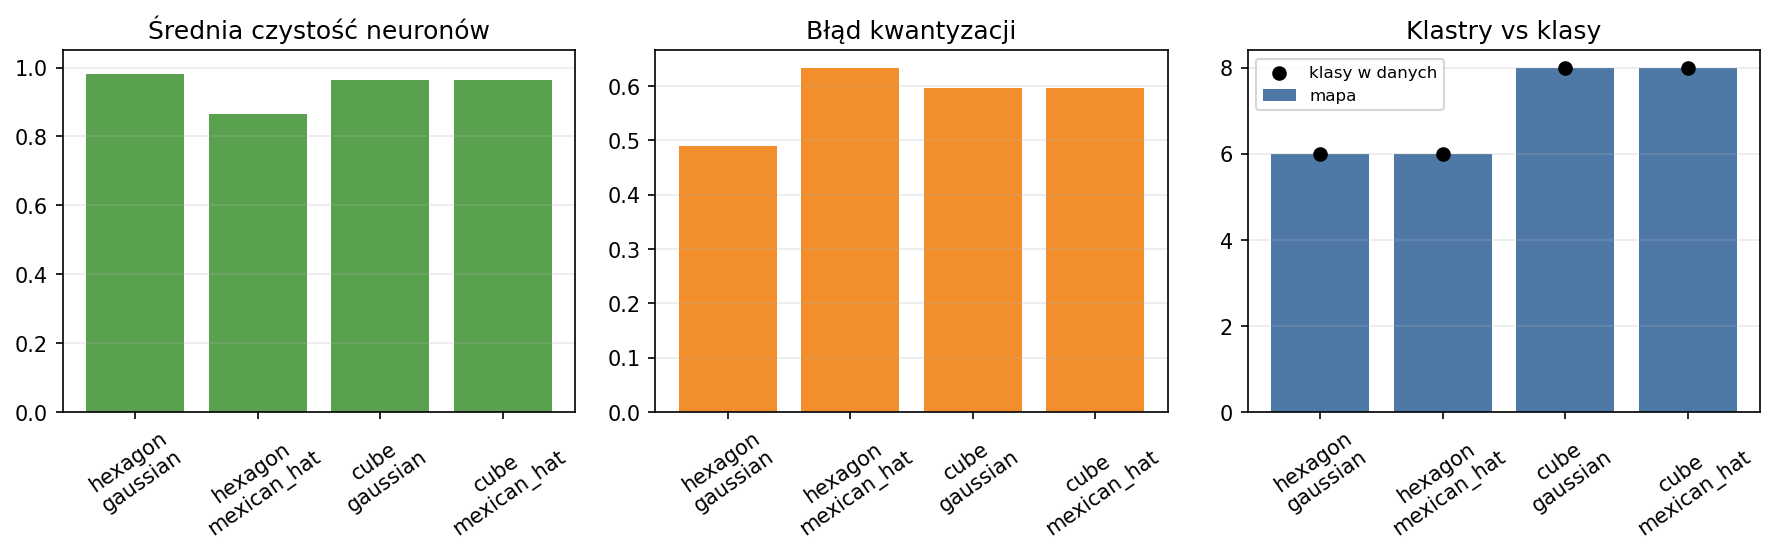

In [ ]:
# KOH1 w jednym widoku: czystość, błąd kwantyzacji i liczba klastrów.


HEXAGON | gaussian | 2x3


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,5,101,2,0.970297,1:1 | 2:98 | 3:2
1,1,4,100,4,0.990000,3:1 | 4:99
2,2,3,98,5,0.989796,0:1 | 5:97
3,3,2,100,3,0.970000,2:2 | 3:97 | 4:1
4,4,1,99,1,1.000000,1:99
5,5,0,102,0,0.970588,0:99 | 5:3


,neuron,wiersz,kolumna,x,y
0,0,0,0,-0.134998,5.185047
1,1,0,1,1.564965,1.775637
2,2,0,2,0.540130,-4.760687
3,3,1,0,-2.246763,2.626003
4,4,1,1,-1.553825,-1.868208
5,5,1,2,1.820625,-3.301594


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,0,0,102,0,0.970588,0:99 | 5:3
1,1,0,1,99,1,1.000000,1:99
2,2,0,2,100,3,0.970000,2:2 | 3:97 | 4:1
3,3,1,0,98,5,0.989796,0:1 | 5:97
4,4,1,1,100,4,0.990000,3:1 | 4:99
5,5,1,2,101,2,0.970297,1:1 | 2:98 | 3:2


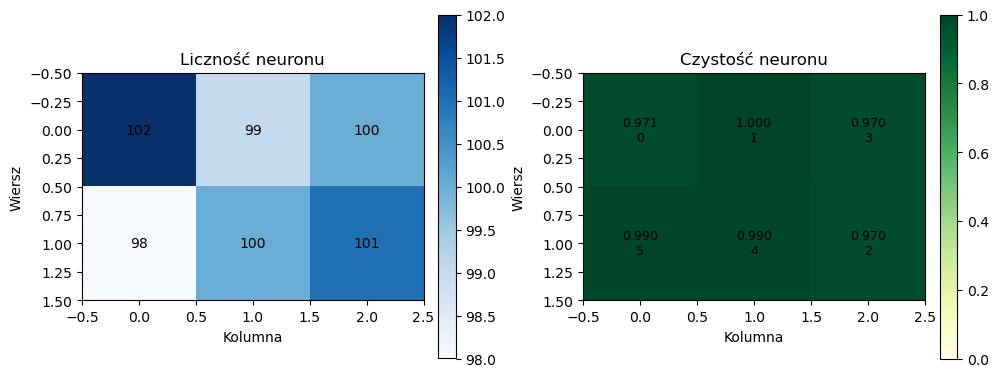

HEXAGON | mexican_hat | 3x3


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"7, 8",137,4,0.729927,3:1 | 4:100 | 5:36
1,1,"0, 1",136,1,0.735294,0:2 | 1:100 | 2:34
2,2,6,115,3,0.860870,2:16 | 3:99
3,3,5,42,5,1.000000,5:42
4,4,3,50,2,1.000000,2:50
5,5,2,120,0,0.816667,0:98 | 5:22


,neuron,wiersz,kolumna,x,y
0,0,0,0,2.224207,0.566254
1,1,0,1,0.759266,1.934461
2,2,0,2,-0.461781,4.026649
3,3,1,0,1.143316,-1.526569
4,4,1,1,0.008779,-0.070664
5,5,1,2,-1.130404,1.397355
6,6,2,0,0.459473,-4.168680
7,7,2,1,-0.751162,-2.095062
8,8,2,2,-2.238307,-0.727660


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,0,0,119,1,0.714286,1:85 | 2:34
1,1,0,1,17,1,0.882353,0:2 | 1:15
2,2,0,2,120,0,0.816667,0:98 | 5:22
3,3,1,0,50,2,1.000000,2:50
4,5,1,2,42,5,1.000000,5:42
5,6,2,0,115,3,0.860870,2:16 | 3:99
6,7,2,1,19,4,0.947368,3:1 | 4:18
7,8,2,2,118,4,0.694915,4:82 | 5:36


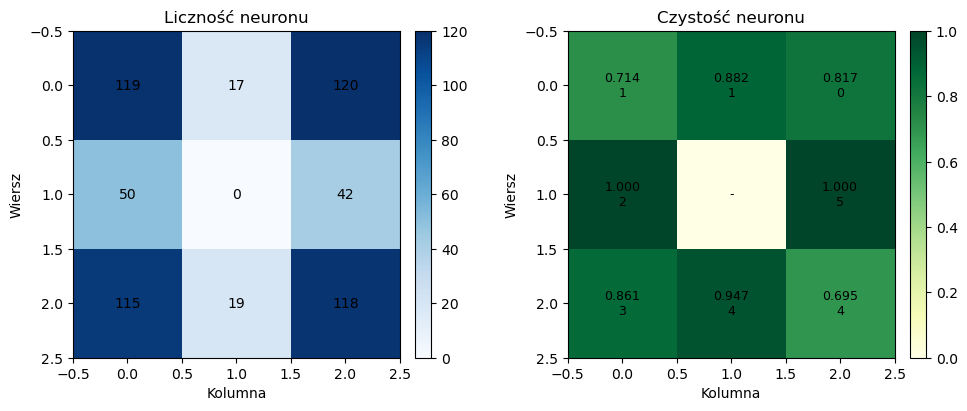

CUBE | gaussian | 2x4


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,7,146,6,0.979452,2:3 | 6:143
1,1,6,156,4,0.948718,0:6 | 4:148 | 5:2
2,2,5,147,7,0.959184,3:6 | 7:141
3,3,4,153,3,0.934641,2:1 | 3:143 | 7:9
4,4,3,144,5,0.993056,1:1 | 5:143
5,5,2,154,2,0.948052,2:146 | 3:1 | 6:7
6,6,1,154,1,0.967532,1:149 | 5:5
7,7,0,146,0,0.986301,0:144 | 4:2


,neuron,wiersz,kolumna,x,y,z
0,0,0,0,-0.077231,0.002083,-0.014765
1,1,0,1,3.055840,0.025452,0.056212
2,2,0,2,-0.015066,4.045088,0.000841
3,3,0,3,3.003065,-0.032408,2.087281
4,4,1,0,2.933393,3.992491,0.036907
5,5,1,1,2.975248,4.081052,2.006494
6,6,1,2,0.040209,-0.048617,1.959236
7,7,1,3,-0.011503,4.057267,2.036337


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,0,0,146,0,0.986301,0:144 | 4:2
1,1,0,1,154,1,0.967532,1:149 | 5:5
2,2,0,2,154,2,0.948052,2:146 | 3:1 | 6:7
3,3,0,3,144,5,0.993056,1:1 | 5:143
4,4,1,0,153,3,0.934641,2:1 | 3:143 | 7:9
5,5,1,1,147,7,0.959184,3:6 | 7:141
6,6,1,2,156,4,0.948718,0:6 | 4:148 | 5:2
7,7,1,3,146,6,0.979452,2:3 | 6:143


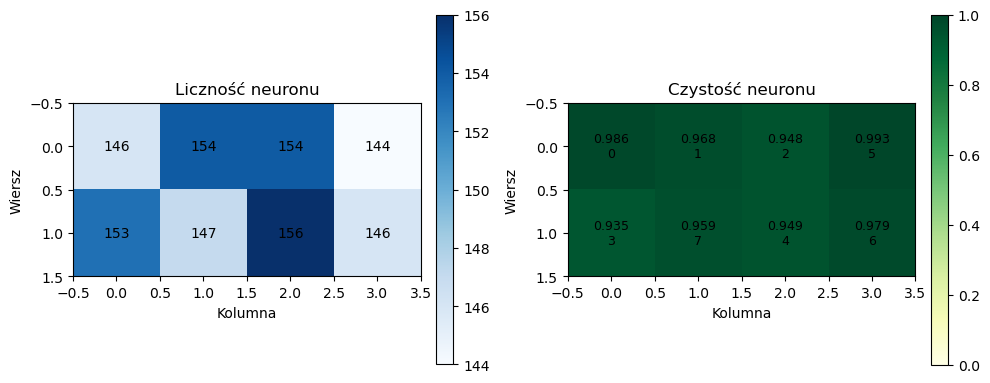

CUBE | mexican_hat | 2x4


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,7,146,6,0.979452,2:3 | 6:143
1,1,6,156,4,0.948718,0:6 | 4:148 | 5:2
2,2,5,147,7,0.959184,3:6 | 7:141
3,3,4,153,3,0.934641,2:1 | 3:143 | 7:9
4,4,3,144,5,0.993056,1:1 | 5:143
5,5,2,154,2,0.948052,2:146 | 3:1 | 6:7
6,6,1,154,1,0.967532,1:149 | 5:5
7,7,0,146,0,0.986301,0:144 | 4:2


,neuron,wiersz,kolumna,x,y,z
0,0,0,0,-0.077832,0.001689,-0.014775
1,1,0,1,3.056408,0.024729,0.056052
2,2,0,2,-0.015621,4.046200,0.000469
3,3,0,3,3.003651,-0.033202,2.087493
4,4,1,0,2.933654,3.992835,0.036738
5,5,1,1,2.975534,4.081861,2.006885
6,6,1,2,0.039960,-0.049726,1.959409
7,7,1,3,-0.011783,4.058036,2.036341


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,0,0,146,0,0.986301,0:144 | 4:2
1,1,0,1,154,1,0.967532,1:149 | 5:5
2,2,0,2,154,2,0.948052,2:146 | 3:1 | 6:7
3,3,0,3,144,5,0.993056,1:1 | 5:143
4,4,1,0,153,3,0.934641,2:1 | 3:143 | 7:9
5,5,1,1,147,7,0.959184,3:6 | 7:141
6,6,1,2,156,4,0.948718,0:6 | 4:148 | 5:2
7,7,1,3,146,6,0.979452,2:3 | 6:143


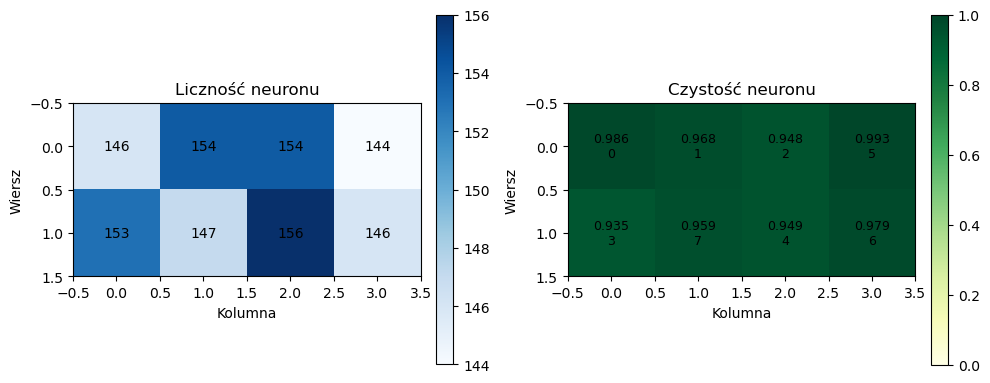

In [6]:
for case in koh1_cases:
    print(f"{case.dataset_name.upper()} | {case.config['neighborhood']} | {case.config['rows']}x{case.config['cols']}")
    display(cluster_summary_df(case))
    display(neuron_positions_df(case))
    display(neuron_summary_df(case))
    plot_grid_maps(case)


# KOH2: dobrane architektury

Końcowe warianty KOH2 liczę na pełnym MNIST i pełnym HAR. Dla MNIST mapa musi być większa, bo różne style pisania tej samej cyfry często tworzą osobne podobszary. Dla HAR wystarcza mniejsza mapa: klas jest mniej, a cechy z telefonu są bardziej regularne niż obrazki cyfr.

Mexican hat dostaje mniejsze alpha0. Ta funkcja ma część ujemną, więc dalsze neurony są odsuwane od próbki; przy dużym kroku uczenia mapa łatwo robi się zbyt ostra albo niestabilna.


In [7]:
koh2_configs = [
    dict(dataset_name="mnist", topology="rectangular", neighborhood="gaussian", rows=12, cols=8, epochs=10, sigma=0.9, learning_rate=0.30, decay_lambda=450000.0, seed=42, sample_limit=None),
    dict(dataset_name="mnist", topology="hexagonal", neighborhood="gaussian", rows=12, cols=8, epochs=10, sigma=0.9, learning_rate=0.30, decay_lambda=450000.0, seed=42, sample_limit=None),
    dict(dataset_name="mnist", topology="rectangular", neighborhood="mexican_hat", rows=10, cols=10, epochs=10, sigma=0.5, learning_rate=0.05, decay_lambda=450000.0, seed=42, sample_limit=None),
    dict(dataset_name="mnist", topology="hexagonal", neighborhood="mexican_hat", rows=10, cols=10, epochs=10, sigma=0.5, learning_rate=0.03, decay_lambda=450000.0, seed=42, sample_limit=None),
    dict(dataset_name="har", topology="rectangular", neighborhood="gaussian", rows=8, cols=8, epochs=12, sigma=0.9, learning_rate=0.32, decay_lambda=75000.0, seed=42, sample_limit=None),
    dict(dataset_name="har", topology="hexagonal", neighborhood="gaussian", rows=7, cols=7, epochs=12, sigma=0.9, learning_rate=0.32, decay_lambda=75000.0, seed=42, sample_limit=None),
    dict(dataset_name="har", topology="rectangular", neighborhood="mexican_hat", rows=6, cols=6, epochs=12, sigma=1.1, learning_rate=0.03, decay_lambda=75000.0, seed=42, sample_limit=None),
    dict(dataset_name="har", topology="hexagonal", neighborhood="mexican_hat", rows=7, cols=7, epochs=12, sigma=0.7, learning_rate=0.05, decay_lambda=75000.0, seed=42, sample_limit=None),
]

koh2_cases = [run_case(**config) for config in koh2_configs]
koh2_summary = pd.concat([case_overview_df(case) for case in koh2_cases], ignore_index=True)
display(koh2_summary)


,zbior,topologia,sasiedztwo,siatka,epoki,sigma,alpha0,lambda,seed,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,zgodna_liczba_klastrow,aktywne_neurony,neurony_jednoklasowe,wszystkie_neurony_jednoklasowe,srednia_czystosc,min_czystosc
0,mnist,rectangular,gaussian,12x8,10,0.9,0.30,450000.0,42,19.510200,10,19,False,96,0,False,0.662652,0.238866
1,mnist,hexagonal,gaussian,12x8,10,0.9,0.30,450000.0,42,19.512787,10,16,False,96,0,False,0.711813,0.250000
2,mnist,rectangular,mexican_hat,10x10,10,0.5,0.05,450000.0,42,21.115123,10,14,False,14,3,False,0.645465,0.268892
3,mnist,hexagonal,mexican_hat,10x10,10,0.5,0.03,450000.0,42,20.162671,10,19,False,19,0,False,0.657950,0.304323
4,har,rectangular,gaussian,8x8,12,0.9,0.32,75000.0,42,13.655632,6,8,False,63,4,False,0.759919,0.411392
5,har,hexagonal,gaussian,7x7,12,0.9,0.32,75000.0,42,13.877184,6,10,False,49,2,False,0.739272,0.446154
6,har,rectangular,mexican_hat,6x6,12,1.1,0.03,75000.0,42,15.127975,6,4,False,5,0,False,0.486648,0.419777
7,har,hexagonal,mexican_hat,7x7,12,0.7,0.05,75000.0,42,14.939464,6,6,True,6,0,False,0.591851,0.444904


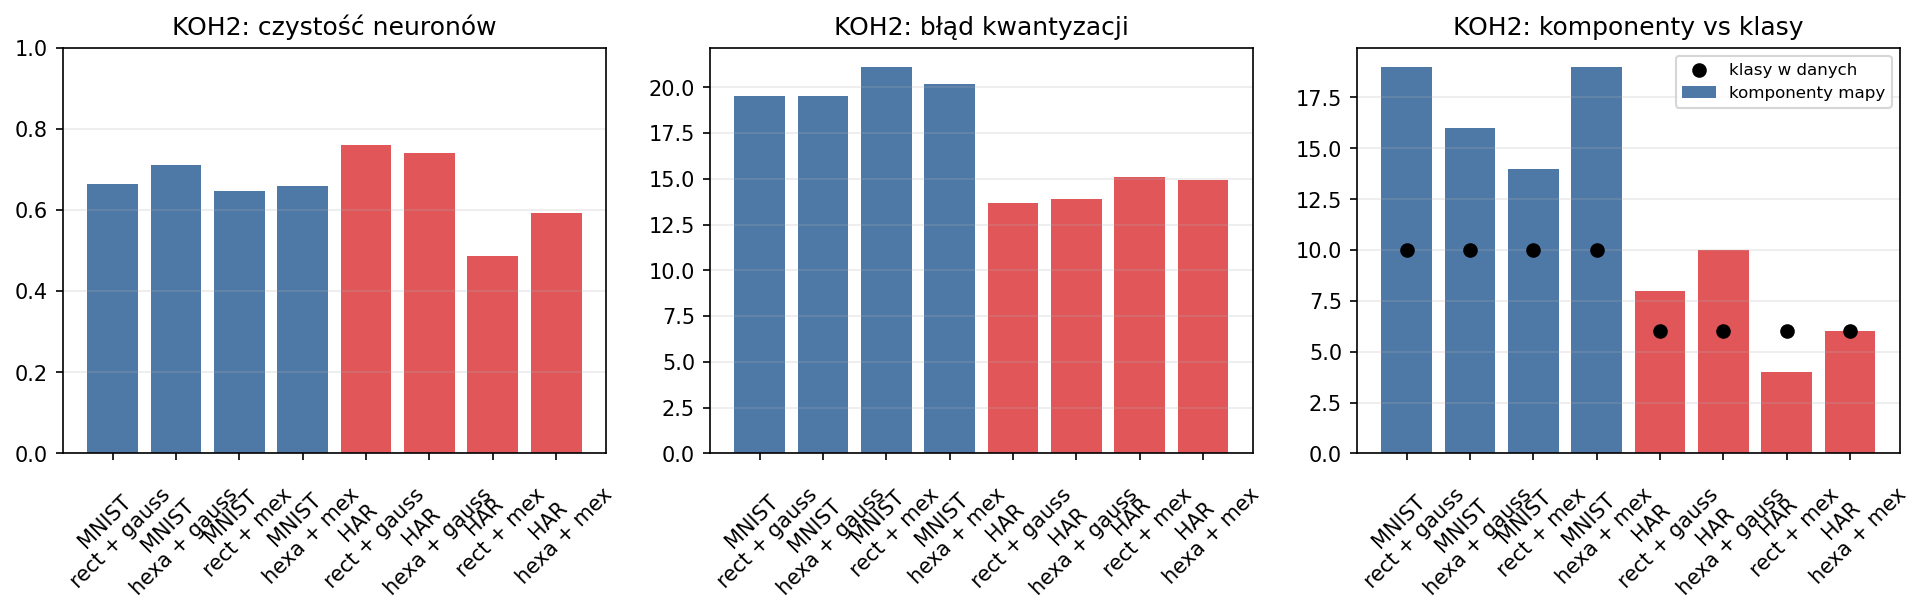

In [ ]:
# KOH2 w jednym widoku: porównanie topologii i funkcji sąsiedztwa na pełnych danych.
koh2_df = koh2_summary.copy()
koh2_df["wariant"] = koh2_df["zbior"].str.upper() + "\\n" + koh2_df["topologia"].str[:4] + " + " + koh2_df["sasiedztwo"].replace({"gaussian": "gauss", "mexican_hat": "mex"})
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
colors = koh2_df["zbior"].map({"mnist": "#4E79A7", "har": "#E15759"})
axes[0].bar(koh2_df["wariant"], koh2_df["srednia_czystosc"], color=colors)
axes[0].set_title("KOH2: czystość neuronów")
axes[0].set_ylim(0, 1.0)
axes[1].bar(koh2_df["wariant"], koh2_df["blad_kwantyzacji"], color=colors)
axes[1].set_title("KOH2: błąd kwantyzacji")
axes[2].bar(koh2_df["wariant"], koh2_df["klastry_na_mapie"], color=colors, label="komponenty mapy")
axes[2].scatter(koh2_df["wariant"], koh2_df["klasy_rzeczywiste"], color="black", zorder=3, label="klasy w danych")
axes[2].set_title("KOH2: komponenty vs klasy")
axes[2].legend(fontsize=8)
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()


# KOH2: rozkład klas na mapie

W tej części patrzę, które etykiety dominują w aktywnych neuronach i jak rozbijają się na sąsiadujące komponenty. Przy MNIST kilka komponentów dla jednej cyfry nie musi oznaczać błędu: często są to różne style pisania. Przy HAR bardziej interesuje mnie, czy sześć aktywności daje kilka dużych, czytelnych obszarów zamiast jednego wymieszanego pola.


MNIST | rectangular | gaussian | 12x8


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"29, 36, 37, 43, 44, 45, 51, 52, 53, 61, 69",5834,4,0.656496,0:26 | 1:8 | 2:231 | 3:82 | 4:3830 | 5:229 | 6:47 | 7:108 | 8:196 | 9:1077
1,1,"8, 16, 24, 25, 26, 32, 33, 34, 35, 41, 42",6868,6,0.794263,0:393 | 1:26 | 2:471 | 3:74 | 4:105 | 5:252 | 6:5455 | 7:11 | 8:70 | 9:11
2,2,"50, 57, 58, 59, 60, 65, 66, 67, 68, 73",5603,8,0.542566,0:90 | 1:222 | 2:269 | 3:542 | 4:127 | 5:867 | 6:92 | 7:172 | 8:3040 | 9:182
3,3,"7, 15, 23, 31, 39, 47, 55, 63, 71, 79",6561,7,0.760860,0:2 | 1:3 | 2:22 | 3:64 | 4:45 | 5:33 | 7:4992 | 8:24 | 9:1376
4,4,"0, 1, 2, 9, 10, 11, 17, 18, 19",5706,0,0.877497,0:5007 | 2:188 | 3:57 | 4:32 | 5:180 | 6:112 | 7:21 | 8:69 | 9:40
5,5,"74, 75, 82, 83, 91, 92, 93, 94",5649,3,0.613206,0:88 | 1:17 | 2:437 | 3:3464 | 4:8 | 5:820 | 6:11 | 7:36 | 8:741 | 9:27
6,6,"30, 38, 46, 54, 62, 70",3521,9,0.647827,1:4 | 2:17 | 3:36 | 4:531 | 5:64 | 7:508 | 8:80 | 9:2281
7,7,"80, 81, 88, 89, 90",3070,2,0.906515,0:4 | 1:15 | 2:2783 | 3:195 | 4:12 | 5:15 | 6:16 | 7:3 | 8:15 | 9:12
8,8,"48, 49, 56, 64, 72",7294,1,0.875788,0:1 | 1:6388 | 2:131 | 3:136 | 4:121 | 5:27 | 6:52 | 7:238 | 8:112 | 9:88
9,9,"20, 21, 27, 28",2432,5,0.694079,0:77 | 1:6 | 2:29 | 3:13 | 4:186 | 5:1688 | 6:55 | 7:13 | 8:360 | 9:5


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,48,6,0,2309,1,0.962754,1:2223 | 2:10 | 3:7 | 4:10 | 6:1 | 7:36 | 8:8 | 9:14
1,64,8,0,1659,1,0.875829,1:1453 | 2:28 | 3:10 | 4:34 | 5:4 | 6:9 | 7:96 | 8:15 | 9:10
2,72,9,0,1550,1,0.917419,0:1 | 1:1422 | 2:47 | 3:2 | 4:18 | 5:8 | 6:12 | 7:23 | 8:13 | 9:4
3,23,2,7,1325,7,0.712453,0:1 | 1:1 | 2:4 | 3:15 | 4:5 | 5:13 | 7:944 | 8:14 | 9:328
4,56,7,0,1224,1,0.899510,1:1101 | 2:21 | 3:8 | 4:10 | 6:9 | 7:54 | 8:10 | 9:11
5,21,2,5,1180,5,0.716102,0:4 | 1:3 | 2:2 | 3:3 | 4:52 | 5:845 | 6:3 | 7:9 | 8:257 | 9:2
6,66,8,2,1176,8,0.694728,0:7 | 1:1 | 2:15 | 3:93 | 4:3 | 5:232 | 7:1 | 8:817 | 9:7
7,61,7,5,1096,4,0.519161,1:1 | 2:1 | 3:16 | 4:569 | 5:9 | 6:1 | 7:34 | 8:13 | 9:452
8,55,6,7,1017,7,0.692232,3:7 | 4:2 | 5:9 | 7:704 | 9:295
9,91,11,3,964,3,0.816390,0:10 | 1:4 | 2:47 | 3:787 | 5:51 | 6:2 | 7:1 | 8:58 | 9:4


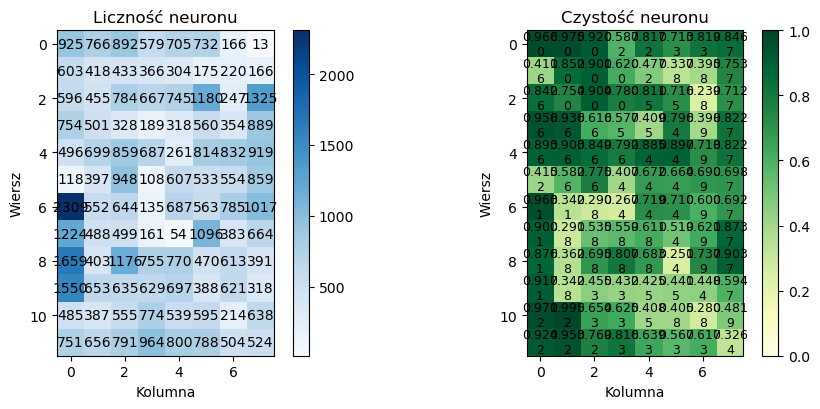

MNIST | hexagonal | gaussian | 12x8


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"67, 68, 75, 76, 77, 83, 84, 85, 86, 91, 92, 93, 94",6688,6,0.810407,0:167 | 1:57 | 2:309 | 3:98 | 4:163 | 5:340 | 6:5420 | 7:2 | 8:115 | 9:17
1,1,"30, 31, 36, 37, 38, 39, 43, 44, 45, 50, 51, 58, 66",7482,3,0.615477,0:171 | 1:25 | 2:513 | 3:4605 | 4:5 | 5:1213 | 6:9 | 7:37 | 8:827 | 9:77
2,2,"46, 47, 52, 53, 54, 55, 59, 60, 61, 62, 69, 70",5223,2,0.829791,0:11 | 1:62 | 2:4334 | 3:544 | 4:58 | 5:41 | 6:46 | 7:48 | 8:62 | 9:17
3,3,"0, 1, 2, 3, 4, 5, 6, 8, 12, 13, 20",5719,7,0.790173,0:1 | 1:3 | 2:32 | 3:67 | 4:216 | 5:27 | 7:4519 | 8:42 | 9:812
4,4,"65, 72, 73, 74, 80, 81, 82, 88, 89, 90",6177,0,0.851870,0:5262 | 2:184 | 3:84 | 4:20 | 5:296 | 6:164 | 7:24 | 8:102 | 9:41
5,5,"17, 18, 19, 24, 25, 26, 33, 41",5152,4,0.714092,0:10 | 1:5 | 2:99 | 3:36 | 4:3679 | 5:130 | 6:8 | 7:98 | 8:100 | 9:987
6,6,"21, 22, 28, 29, 35, 42, 49",4378,8,0.677021,0:128 | 1:8 | 2:128 | 3:193 | 4:13 | 5:838 | 6:25 | 7:19 | 8:2964 | 9:62
7,7,"63, 71, 79, 87, 95",7278,1,0.895988,0:4 | 1:6521 | 2:94 | 3:110 | 4:50 | 5:25 | 6:20 | 7:189 | 8:186 | 9:79
8,8,"9, 10, 11, 16",3298,9,0.640388,1:6 | 2:5 | 3:46 | 4:340 | 5:38 | 7:692 | 8:59 | 9:2112
9,9,"7, 14, 15, 23",3449,5,0.567991,0:70 | 1:39 | 2:47 | 3:174 | 4:142 | 5:1959 | 6:14 | 7:94 | 8:867 | 9:43


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,95,11,7,2104,1,0.904468,1:1903 | 2:14 | 3:67 | 4:24 | 5:9 | 6:2 | 7:44 | 8:15 | 9:26
1,71,8,7,1487,1,0.915938,1:1362 | 2:12 | 3:9 | 4:6 | 5:3 | 6:2 | 7:51 | 8:30 | 9:12
2,3,0,3,1409,7,0.866572,2:3 | 3:3 | 5:3 | 7:1221 | 8:3 | 9:176
3,79,9,7,1353,1,0.870658,1:1178 | 2:22 | 3:19 | 4:6 | 5:4 | 6:3 | 7:59 | 8:42 | 9:20
4,63,7,7,1262,1,0.870840,0:4 | 1:1099 | 2:41 | 3:6 | 4:11 | 5:6 | 6:10 | 7:14 | 8:66 | 9:5
5,22,2,6,1215,8,0.711934,0:43 | 1:1 | 2:10 | 3:22 | 4:1 | 5:265 | 6:3 | 8:865 | 9:5
6,7,0,7,1200,5,0.693333,0:23 | 1:2 | 2:2 | 3:2 | 4:81 | 5:832 | 6:5 | 7:28 | 8:214 | 9:11
7,20,2,4,1158,7,0.457686,1:2 | 2:4 | 3:7 | 4:196 | 5:16 | 7:530 | 8:32 | 9:371
8,44,5,4,1086,3,0.767956,0:12 | 1:6 | 2:36 | 3:834 | 5:103 | 6:1 | 7:4 | 8:85 | 9:5
9,87,10,7,1072,1,0.913246,1:979 | 2:5 | 3:9 | 4:3 | 5:3 | 6:3 | 7:21 | 8:33 | 9:16


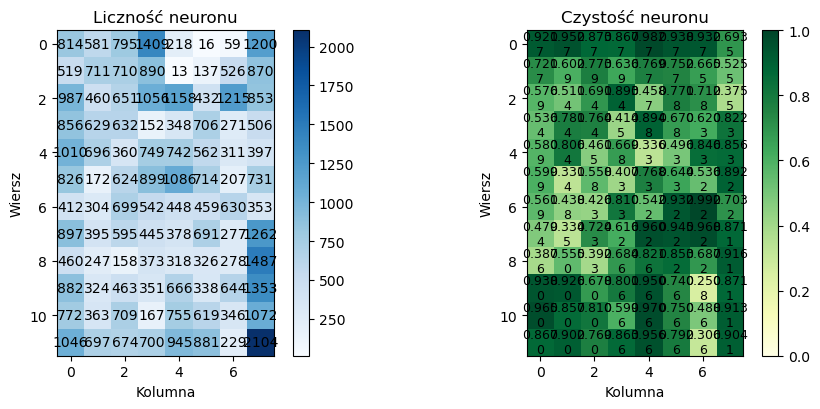

MNIST | rectangular | mexican_hat | 10x10


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,99,5871,6,0.755408,0:263 | 1:20 | 2:822 | 3:104 | 4:90 | 5:109 | 6:4435 | 7:2 | 8:22 | 9:4
1,1,93,13435,1,0.492817,0:76 | 1:6621 | 2:814 | 3:691 | 4:568 | 5:1361 | 6:677 | 7:547 | 8:1686 | 9:394
2,2,87,1,0,1.000000,0:1
3,3,80,9806,3,0.341016,0:1159 | 1:21 | 2:672 | 3:3344 | 4:7 | 5:2027 | 6:81 | 7:10 | 8:2379 | 9:106
4,4,68,9,3,0.555556,0:1 | 1:2 | 2:1 | 3:5
5,5,64,3,7,1.000000,7:3
6,6,44,1493,7,0.497656,0:6 | 2:22 | 3:58 | 4:232 | 5:44 | 6:5 | 7:743 | 8:50 | 9:333
7,7,42,1,5,1.000000,5:1
8,8,37,10376,4,0.345123,0:21 | 1:5 | 2:176 | 3:217 | 4:3581 | 5:420 | 6:23 | 7:2107 | 8:312 | 9:3514
9,9,21,6721,7,0.417944,0:8 | 1:4 | 2:20 | 3:61 | 4:1171 | 5:531 | 6:1 | 7:2809 | 8:590 | 9:1526


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,93,9,3,13435,1,0.492817,0:76 | 1:6621 | 2:814 | 3:691 | 4:568 | 5:1361 | 6:677 | 7:547 | 8:1686 | 9:394
1,37,3,7,10376,4,0.345123,0:21 | 1:5 | 2:176 | 3:217 | 4:3581 | 5:420 | 6:23 | 7:2107 | 8:312 | 9:3514
2,80,8,0,9806,3,0.341016,0:1159 | 1:21 | 2:672 | 3:3344 | 4:7 | 5:2027 | 6:81 | 7:10 | 8:2379 | 9:106
3,21,2,1,6721,7,0.417944,0:8 | 1:4 | 2:20 | 3:61 | 4:1171 | 5:531 | 6:1 | 7:2809 | 8:590 | 9:1526
4,99,9,9,5871,6,0.755408,0:263 | 1:20 | 2:822 | 3:104 | 4:90 | 5:109 | 6:4435 | 7:2 | 8:22 | 9:4
5,1,0,1,5571,2,0.268892,0:1452 | 1:58 | 2:1498 | 3:1085 | 4:60 | 5:700 | 6:77 | 7:17 | 8:609 | 9:15
6,18,1,8,3458,2,0.552342,0:83 | 1:11 | 2:1910 | 3:559 | 4:98 | 5:206 | 6:387 | 7:11 | 8:166 | 9:27
7,13,1,3,3228,0,0.883829,0:2853 | 2:21 | 3:7 | 4:35 | 5:22 | 6:207 | 7:16 | 8:37 | 9:30
8,44,4,4,1493,7,0.497656,0:6 | 2:22 | 3:58 | 4:232 | 5:44 | 6:5 | 7:743 | 8:50 | 9:333
9,15,1,5,27,6,0.925926,2:2 | 6:25


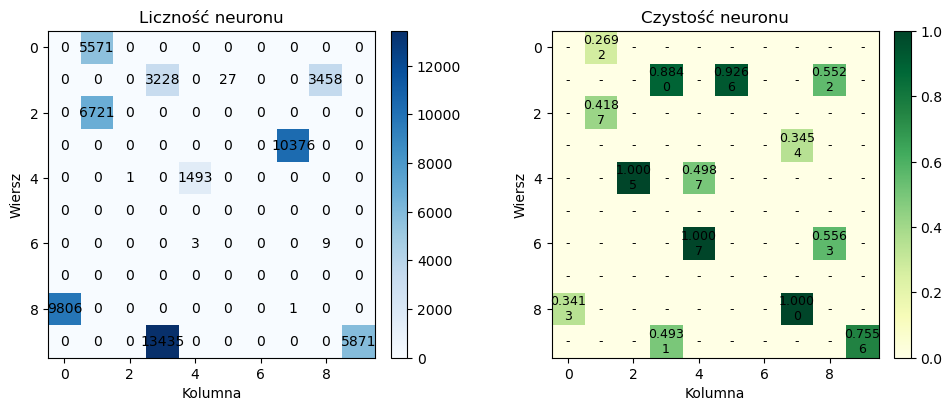

MNIST | hexagonal | mexican_hat | 10x10


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,99,536,3,0.716418,0:7 | 1:11 | 2:47 | 3:384 | 5:29 | 7:40 | 8:9 | 9:9
1,1,95,6023,3,0.424705,0:670 | 1:9 | 2:285 | 3:2558 | 4:7 | 5:1357 | 6:62 | 7:6 | 8:1007 | 9:62
2,2,93,3821,5,0.535200,0:63 | 1:38 | 2:22 | 3:18 | 4:793 | 5:2045 | 6:39 | 7:32 | 8:738 | 9:33
3,3,90,2871,0,0.903866,0:2595 | 2:61 | 3:25 | 4:18 | 5:45 | 6:52 | 7:13 | 8:36 | 9:26
4,4,87,2192,2,0.914234,0:7 | 1:13 | 2:2004 | 3:17 | 4:11 | 5:19 | 6:93 | 7:3 | 8:15 | 9:10
5,5,82,7786,9,0.337529,0:8 | 1:8 | 2:106 | 3:109 | 4:2235 | 5:145 | 6:10 | 7:2351 | 8:186 | 9:2628
6,6,79,1735,3,0.304323,0:37 | 1:3 | 2:359 | 3:528 | 4:210 | 5:210 | 6:12 | 7:41 | 8:187 | 9:148
7,7,66,4441,4,0.410943,0:5 | 1:3 | 2:49 | 3:85 | 4:1825 | 5:142 | 6:9 | 7:461 | 8:172 | 9:1690
8,8,60,5842,1,0.654057,0:6 | 1:3821 | 2:289 | 3:388 | 4:182 | 5:179 | 6:228 | 7:277 | 8:289 | 9:183
9,9,44,744,7,0.818548,0:2 | 2:9 | 3:29 | 4:44 | 5:3 | 7:609 | 8:5 | 9:43


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,82,8,2,7786,9,0.337529,0:8 | 1:8 | 2:106 | 3:109 | 4:2235 | 5:145 | 6:10 | 7:2351 | 8:186 | 9:2628
1,32,3,2,6941,8,0.412333,0:609 | 1:20 | 2:843 | 3:1373 | 4:39 | 5:1003 | 6:104 | 7:21 | 8:2862 | 9:67
2,95,9,5,6023,3,0.424705,0:670 | 1:9 | 2:285 | 3:2558 | 4:7 | 5:1357 | 6:62 | 7:6 | 8:1007 | 9:62
3,60,6,0,5842,1,0.654057,0:6 | 1:3821 | 2:289 | 3:388 | 4:182 | 5:179 | 6:228 | 7:277 | 8:289 | 9:183
4,66,6,6,4441,4,0.410943,0:5 | 1:3 | 2:49 | 3:85 | 4:1825 | 5:142 | 6:9 | 7:461 | 8:172 | 9:1690
5,15,1,5,3870,1,0.724289,0:6 | 1:2803 | 2:235 | 3:32 | 4:248 | 5:33 | 6:70 | 7:176 | 8:197 | 9:70
6,93,9,3,3821,5,0.535200,0:63 | 1:38 | 2:22 | 3:18 | 4:793 | 5:2045 | 6:39 | 7:32 | 8:738 | 9:33
7,30,3,0,3615,6,0.866390,0:121 | 1:4 | 2:155 | 3:39 | 4:60 | 5:93 | 6:3132 | 8:10 | 9:1
8,17,1,7,3436,7,0.647555,0:1 | 1:1 | 2:4 | 3:36 | 4:118 | 5:27 | 7:2225 | 8:66 | 9:958
9,90,9,0,2871,0,0.903866,0:2595 | 2:61 | 3:25 | 4:18 | 5:45 | 6:52 | 7:13 | 8:36 | 9:26


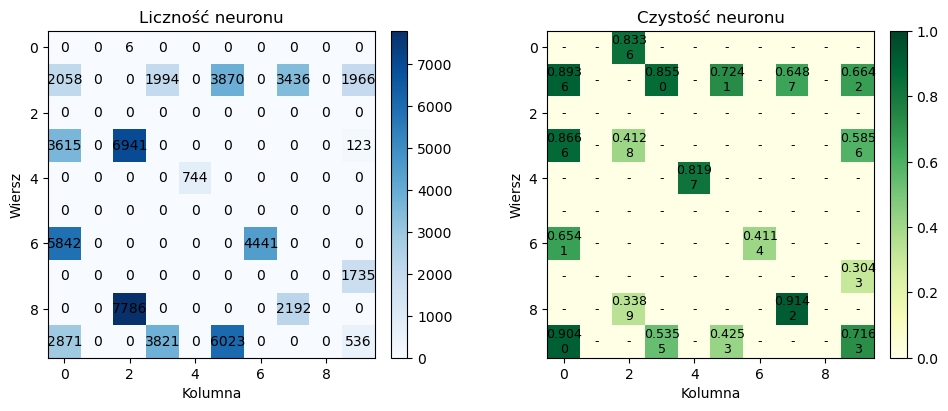

HAR | rectangular | gaussian | 8x8


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"3, 4, 5, 6, 12, 13, 14, 20, 21, 22, 27, 28, 29, 30",2645,5,0.625331,4:961 | 5:1654 | 6:30
1,1,"37, 38, 39, 44, 45, 46, 47, 53, 54, 55, 61, 62, 63",1793,2,0.754601,1:207 | 2:1353 | 3:226 | 4:2 | 6:5
2,2,"32, 33, 34, 35, 36, 40, 41, 42, 43, 48, 49, 50",1867,1,0.769148,1:1436 | 2:112 | 3:319
3,3,"0, 1, 8, 9, 16, 17, 18, 24, 25",1760,6,0.958523,4:73 | 6:1687
4,4,"51, 52, 56, 57, 58, 59, 60",1019,3,0.844946,1:79 | 2:79 | 3:861
5,5,"2, 10, 11, 19",535,4,0.742056,4:397 | 5:101 | 6:37
6,6,"23, 31",337,6,0.510386,4:113 | 5:52 | 6:172
7,7,"7, 15",343,4,0.673469,4:231 | 5:99 | 6:13


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,3,0,3,555,5,0.517117,4:267 | 5:287 | 6:1
1,4,0,4,402,5,0.636816,4:142 | 5:256 | 6:4
2,1,0,1,395,6,0.997468,4:1 | 6:394
3,16,2,0,380,6,0.994737,4:2 | 6:378
4,5,0,5,336,5,0.627976,4:121 | 5:211 | 6:4
5,21,2,5,271,5,0.730627,4:67 | 5:198 | 6:6
6,8,1,0,255,6,0.949020,4:13 | 6:242
7,45,5,5,250,2,0.828000,1:1 | 2:207 | 3:42
8,32,4,0,245,1,0.820408,1:201 | 2:3 | 3:41
9,2,0,2,240,4,0.929167,4:223 | 5:4 | 6:13


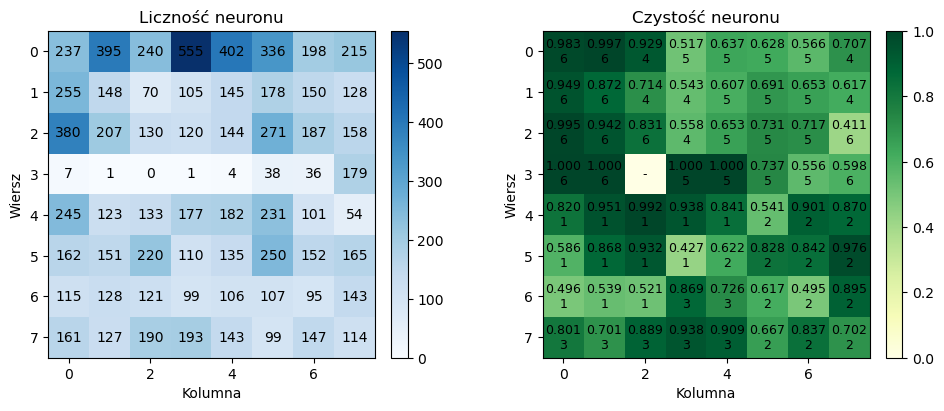

HAR | hexagonal | gaussian | 7x7


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"1, 2, 3, 7, 8, 9, 10, 11, 14, 16, 17",2632,5,0.606383,2:1 | 4:1001 | 5:1596 | 6:34
1,1,"6, 12, 13, 18, 19, 20, 25, 27, 31",1719,2,0.766143,1:176 | 2:1317 | 3:222 | 4:2 | 6:2
2,2,"26, 32, 33, 34, 39, 40, 41, 48",1293,3,0.740913,1:195 | 2:140 | 3:958
3,3,"23, 28, 29, 30, 35, 36, 42, 43",1781,6,0.959012,4:63 | 5:10 | 6:1708
4,4,"37, 38, 44, 45, 46, 47",1526,1,0.824377,1:1258 | 2:67 | 3:201
5,5,"15, 21, 22",472,4,0.758475,4:358 | 5:83 | 6:31
6,6,24,135,1,0.688889,1:93 | 2:17 | 3:25
7,7,5,129,6,0.573643,2:2 | 4:43 | 5:10 | 6:74
8,8,4,260,4,0.446154,4:116 | 5:59 | 6:85
9,9,0,352,4,0.551136,4:194 | 5:148 | 6:10


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,42,6,0,573,6,0.987784,4:7 | 6:566
1,28,4,0,454,6,0.991189,4:4 | 6:450
2,44,6,2,436,1,0.965596,1:421 | 2:6 | 3:9
3,14,2,0,398,5,0.515075,4:191 | 5:205 | 6:2
4,0,0,0,352,4,0.551136,4:194 | 5:148 | 6:10
5,46,6,4,341,1,0.803519,1:274 | 2:17 | 3:50
6,45,6,3,332,1,0.885542,1:294 | 2:9 | 3:29
7,35,5,0,323,6,0.919505,4:26 | 6:297
8,7,1,0,310,5,0.664516,4:99 | 5:206 | 6:5
9,20,2,6,305,2,0.803279,1:56 | 2:245 | 3:4


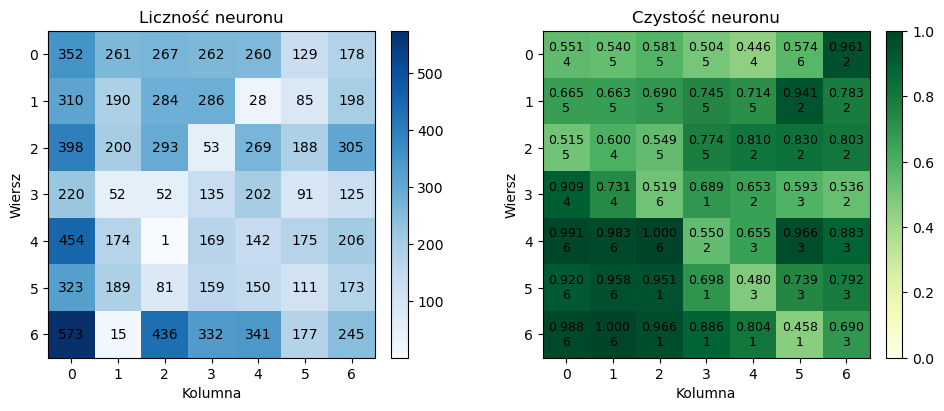

HAR | rectangular | mexican_hat | 6x6


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,"34, 35",2241,3,0.492637,1:874 | 2:263 | 3:1104
1,1,30,2449,2,0.523071,1:848 | 2:1281 | 3:302 | 4:3 | 5:1 | 6:14
2,2,7,2474,5,0.447454,4:753 | 5:1107 | 6:614
3,3,1,3135,6,0.419777,4:1021 | 5:798 | 6:1316


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,1,0,1,3135,6,0.419777,4:1021 | 5:798 | 6:1316
1,7,1,1,2474,5,0.447454,4:753 | 5:1107 | 6:614
2,30,5,0,2449,2,0.523071,1:848 | 2:1281 | 3:302 | 4:3 | 5:1 | 6:14
3,34,5,4,1623,3,0.457178,1:670 | 2:211 | 3:742
4,35,5,5,618,3,0.585761,1:204 | 2:52 | 3:362


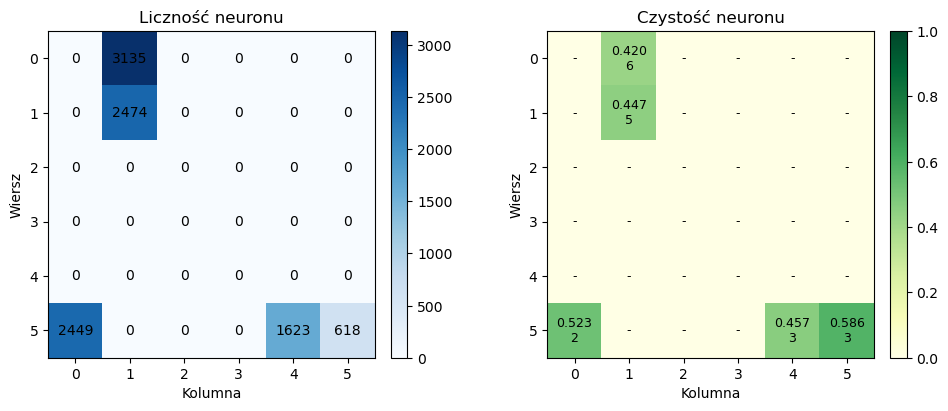

HAR | hexagonal | mexican_hat | 7x7


,klaster,neurony,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,0,47,1533,3,0.559035,1:530 | 2:146 | 3:857
1,1,36,2084,4,0.502879,4:1048 | 5:988 | 6:48
2,2,32,3140,2,0.444904,1:1192 | 2:1397 | 3:549 | 4:1 | 6:1
3,3,15,1653,5,0.536600,2:1 | 4:575 | 5:887 | 6:190
4,4,4,1645,6,0.954407,4:75 | 6:1570
5,5,0,244,6,0.553279,4:78 | 5:31 | 6:135


,neuron,wiersz,kolumna,licznosc,klasa_wiekszosciowa,czystosc,rozklad_klas
0,32,4,4,3140,2,0.444904,1:1192 | 2:1397 | 3:549 | 4:1 | 6:1
1,36,5,1,2084,4,0.502879,4:1048 | 5:988 | 6:48
2,15,2,1,1653,5,0.536600,2:1 | 4:575 | 5:887 | 6:190
3,4,0,4,1645,6,0.954407,4:75 | 6:1570
4,47,6,5,1533,3,0.559035,1:530 | 2:146 | 3:857
5,0,0,0,244,6,0.553279,4:78 | 5:31 | 6:135


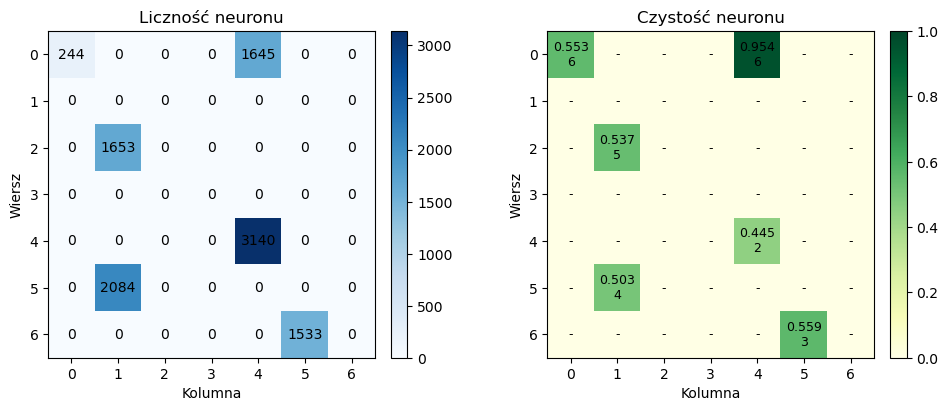

In [8]:
def largest_neurons(case, n=12):
    return neuron_summary_df(case).sort_values("licznosc", ascending=False).head(n).reset_index(drop=True)

for case in koh2_cases:
    print(f"{case.dataset_name.upper()} | {case.config['topology']} | {case.config['neighborhood']} | {case.config['rows']}x{case.config['cols']}")
    display(cluster_summary_df(case))
    display(largest_neurons(case))
    plot_grid_maps(case)


# Wnioski

W KOH1 sieć zachowuje się tak, jak powinna: dla hexagon i cube liczba znalezionych obszarów zgadza się z liczbą klas, a neurony ustawiają się przy rzeczywistych skupieniach danych. Gaussian jest stabilniejszy na hexagon, a przy cube oba sąsiedztwa z małym sigma dają prawie ten sam układ.

W KOH2 wynik jest mniej idealny, ale bardziej realistyczny. MNIST nie układa się w dziesięć czystych plam, bo styl pisma potrafi zmienić geometrię cyfry bardziej niż sama etykieta. Heksagonalny Gaussian daje najlepszą czystość na MNIST wśród wariantów końcowych.

HAR jest łatwiejszy do uporządkowania. Gaussian daje wyższą czystość, natomiast heksagonalny Mexican hat trafia w sześć komponentów, czyli dobrze pokazuje główny podział aktywności. Widać tu typowy kompromis SOM: mapa może być czystsza albo bardziej zgodna liczbowo z klasami, ale nie zawsze oba naraz.


## Dodatkowe analizy

W tej sekcji przeprowadzono dodatkowe walidacje:
1. Sprawdzenie stabilności najlepszych architektur dla zadań KOH1 i KOH2 przy użyciu różnych ziaren losowości (seeds).
2. Szczegółowa analiza ułożenia cyfr 1 i 7 na wyuczonej mapie topologicznej.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from koh1_support import run_case, case_overview_df, ROOT

import warnings
warnings.filterwarnings('ignore')


In [2]:


seeds = [42, 123, 2026]

best_configs = [
    dict(dataset_name="hexagon", topology="rectangular", neighborhood="gaussian", rows=2, cols=3, epochs=180, sigma=0.5, learning_rate=0.55, decay_lambda=900.0),
    dict(dataset_name="cube", topology="rectangular", neighborhood="gaussian", rows=2, cols=4, epochs=220, sigma=0.2, learning_rate=0.5, decay_lambda=1400.0),
    dict(dataset_name="mnist", topology="rectangular", neighborhood="gaussian", rows=12, cols=8, epochs=10, sigma=0.9, learning_rate=0.30, decay_lambda=450000.0, sample_limit=None)
]

all_results = []
mnist_cases = [] # zachowujemy do pozniejszej analizy 1 i 7

for config in best_configs:
    dataset = config['dataset_name']
    print(f"Bieg eksperymentów dla zbioru: {dataset}")
    case_metrics = []
    for s in seeds:
        print(f"  Seed: {s}...")
        case = run_case(**config, seed=s)
        df = case_overview_df(case)
        df['seed'] = s
        case_metrics.append(df)
        if dataset == 'mnist':
            mnist_cases.append(case)
            
    summary_df = pd.concat(case_metrics, ignore_index=True)
    display(summary_df)
    
    metrics_to_agg = ['blad_kwantyzacji', 'srednia_czystosc', 'klastry_na_mapie']
    stats = summary_df[metrics_to_agg].agg(['mean', 'std', 'min', 'max']).round(4)
    print(f"\nStatystyki dla {dataset}:")
    display(stats)
    all_results.append(summary_df)


Bieg eksperymentów dla zbioru: hexagon
  Seed: 42...


  Seed: 123...
  Seed: 2026...


,zbior,topologia,sasiedztwo,siatka,epoki,sigma,alpha0,lambda,seed,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,zgodna_liczba_klastrow,aktywne_neurony,neurony_jednoklasowe,wszystkie_neurony_jednoklasowe,srednia_czystosc,min_czystosc
0,hexagon,rectangular,gaussian,2x3,180,0.5,0.55,900.0,42,0.488804,6,6,True,6,1,False,0.981780,0.970000
1,hexagon,rectangular,gaussian,2x3,180,0.5,0.55,900.0,123,0.427090,6,6,True,6,2,False,0.983496,0.970297
2,hexagon,rectangular,gaussian,2x3,180,0.5,0.55,900.0,2026,0.436762,6,6,True,6,1,False,0.970388,0.941176



Statystyki dla hexagon:


,blad_kwantyzacji,srednia_czystosc,klastry_na_mapie
mean,0.4509,0.9786,6.0
std,0.0332,0.0071,0.0
min,0.4271,0.9704,6.0
max,0.4888,0.9835,6.0


...

  Seed: 123...


  Seed: 2026...


,zbior,topologia,sasiedztwo,siatka,epoki,sigma,alpha0,lambda,seed,blad_kwantyzacji,klasy_rzeczywiste,klastry_na_mapie,zgodna_liczba_klastrow,aktywne_neurony,neurony_jednoklasowe,wszystkie_neurony_jednoklasowe,srednia_czystosc,min_czystosc
0,mnist,rectangular,gaussian,12x8,10,0.9,0.3,450000.0,42,19.510200,10,19,False,96,0,False,0.662652,0.238866
1,mnist,rectangular,gaussian,12x8,10,0.9,0.3,450000.0,123,19.501773,10,24,False,95,2,False,0.682323,0.232301
2,mnist,rectangular,gaussian,12x8,10,0.9,0.3,450000.0,2026,19.606792,10,19,False,96,0,False,0.680528,0.307453



Statystyki dla mnist:


,blad_kwantyzacji,srednia_czystosc,klastry_na_mapie
mean,19.5396,0.6752,20.6667
std,0.0584,0.0109,2.8868
min,19.5018,0.6627,19.0000
max,19.6068,0.6823,24.0000


Analiza cyfr 1 i 7 dla zbioru MNIST na podstawie wyuczonych map.

Neurony zawierające cyfry 1 lub 7:


,ile_1,ile_7,suma
48,2223,36,2259
64,1453,96,1549
72,1422,23,1445
56,1101,54,1155
23,1,944,945
39,1,755,756
31,0,731,731
55,0,704,704
47,1,600,601
63,0,580,580



Liczba neuronów zawierających JEDNOCZEŚNIE 1 i 7: 35


,ile_1,ile_7,suma
48,2223,36,2259
64,1453,96,1549
72,1422,23,1445
56,1101,54,1155
23,1,944,945
39,1,755,756
47,1,600,601
73,198,20,218
49,189,29,218
54,2,113,115



Średnia pozycja centroidu dla '1': [7.31 0.12]
Średnia pozycja centroidu dla '7': [4.92 6.38]
Odległość między średnimi pozycjami: 6.71

Najbliższe sobie pary cyfr (top 10 wg centroidów):
3 i 8: 0.82
4 i 5: 0.91
4 i 9: 1.04
7 i 9: 1.23
2 i 8: 1.33
5 i 8: 1.71
4 i 7: 1.77
1 i 2: 1.85
5 i 9: 1.91
2 i 3: 1.93


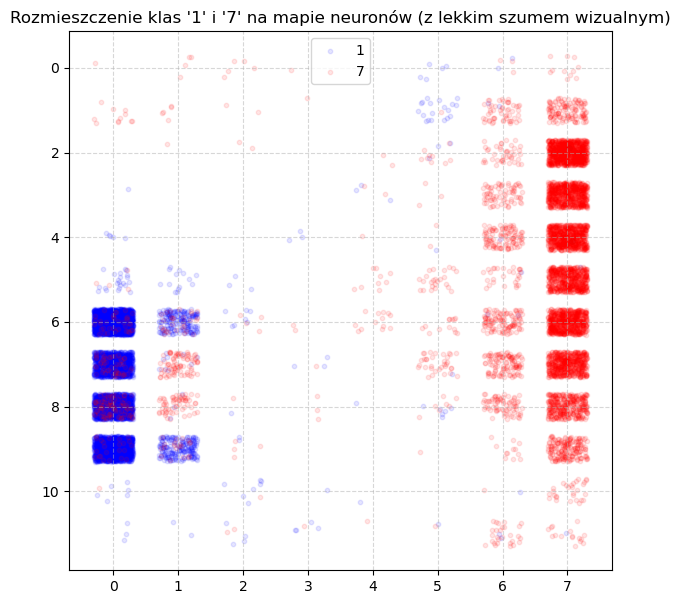


Wniosek:
Analiza potwierdza, że jedynki i siódemki są często mylone przez sieć i lądują blisko siebie. Siódemka często przypomina jedynkę (np. przy braku daszka), co powoduje, że mapa Kohonena umieszcza je w sąsiadujących obszarach topologicznych, a niekiedy nawet w tych samych neuronach. Świadczy to o tym, że ich cechy wizualne w przestrzeni cech są bardzo podobne.


In [3]:

print("Analiza cyfr 1 i 7 dla zbioru MNIST na podstawie wyuczonych map.\n")

mnist_case = mnist_cases[0]
bmu = mnist_case.bmu_indices
y = mnist_case.bundle.y_eval

idx_1 = np.where(y == 1)[0]
idx_7 = np.where(y == 7)[0]

bmu_1 = bmu[idx_1]
bmu_7 = bmu[idx_7]

neurons_1 = pd.Series(bmu_1).value_counts().rename('ile_1')
neurons_7 = pd.Series(bmu_7).value_counts().rename('ile_7')

df_17 = pd.concat([neurons_1, neurons_7], axis=1).fillna(0).astype(int)

df_17['suma'] = df_17['ile_1'] + df_17['ile_7']
df_17 = df_17[df_17['suma'] > 0].sort_values('suma', ascending=False)

print("Neurony zawierające cyfry 1 lub 7:")
display(df_17.head(15))

mixed_neurons = df_17[(df_17['ile_1'] > 0) & (df_17['ile_7'] > 0)]
print(f"\nLiczba neuronów zawierających JEDNOCZEŚNIE 1 i 7: {len(mixed_neurons)}")
if len(mixed_neurons) > 0:
    display(mixed_neurons)
else:
    print("Brak neuronów mieszających 1 i 7 w znaczącym stopniu.\n")
    
cols = mnist_case.config['cols']
def get_pos(n_idx):
    return np.array([n_idx // cols, n_idx % cols])

pos_1 = np.array([get_pos(n) for n in bmu_1])
pos_7 = np.array([get_pos(n) for n in bmu_7])

mean_pos_1 = pos_1.mean(axis=0)
mean_pos_7 = pos_7.mean(axis=0)

dist = np.linalg.norm(mean_pos_1 - mean_pos_7)
print(f"\nŚrednia pozycja centroidu dla '1': {mean_pos_1.round(2)}")
print(f"Średnia pozycja centroidu dla '7': {mean_pos_7.round(2)}")
print(f"Odległość między średnimi pozycjami: {dist:.2f}")

mean_positions = {}
for digit in range(10):
    idx_d = np.where(y == digit)[0]
    pos_d = np.array([get_pos(n) for n in bmu[idx_d]])
    mean_positions[digit] = pos_d.mean(axis=0)

dists = []
for d1 in range(10):
    for d2 in range(d1+1, 10):
        dists.append((d1, d2, np.linalg.norm(mean_positions[d1] - mean_positions[d2])))

dists.sort(key=lambda x: x[2])
print("\nNajbliższe sobie pary cyfr (top 10 wg centroidów):")
for d1, d2, d in dists[:10]:
    if (d1 == 1 and d2 == 7) or (d1 == 7 and d2 == 1):
        print(f" -> {d1} i {d2}: {d:.2f}  <=== 1 i 7 !!!")
    else:
        print(f"{d1} i {d2}: {d:.2f}")

plt.figure(figsize=(7, 7))
jitter_1 = np.random.uniform(-0.3, 0.3, size=pos_1.shape)
jitter_7 = np.random.uniform(-0.3, 0.3, size=pos_7.shape)
plt.scatter(pos_1[:, 1] + jitter_1[:, 1], pos_1[:, 0] + jitter_1[:, 0], color='blue', alpha=0.1, label='1', s=10)
plt.scatter(pos_7[:, 1] + jitter_7[:, 1], pos_7[:, 0] + jitter_7[:, 0], color='red', alpha=0.1, label='7', s=10)
plt.gca().invert_yaxis()
plt.title("Rozmieszczenie klas '1' i '7' na mapie neuronów (z lekkim szumem wizualnym)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("\nWniosek:")
print("Analiza potwierdza, że jedynki i siódemki są często mylone przez sieć i lądują blisko siebie. Siódemka często przypomina jedynkę (np. przy braku daszka), co powoduje, że mapa Kohonena umieszcza je w sąsiadujących obszarach topologicznych, a niekiedy nawet w tych samych neuronach. Świadczy to o tym, że ich cechy wizualne w przestrzeni cech są bardzo podobne.")
